# Malaysian Motor Insurance Dataset Generation (2021-2025)

## Overview
This notebook generates a comprehensive synthetic motor insurance dataset covering:
- **100,000+ policies** across 2021-2025
- **364 vehicle models** from cars.csv master table
- **No Claims Discount (NCD)** progression tracking
- **10 interconnected tables** for actuarial modeling

## Database Tables Generated:
1. **policies** - Core policy records with premiums, claims, NCD
2. **vehicles** - Vehicle master table with safety features
3. **claim_frequency** - Frequency modeling aggregates
4. **claim_severity** - Severity modeling aggregates
5. **expenses** - Annual expense ratios
6. **rating_conversion** - Rating factor points
7. **temporal_exposure** - Quarterly exposure breakdowns
8. **claims** - Peril-level claim records
9. **external_data** - Driver/vehicle external attributes
10. **trip_telemetry** - EV telematics data (UBI)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from datetime import datetime, timedelta
import warnings
import os
os.makedirs('images', exist_ok=True)
import uuid

warnings.filterwarnings('ignore')
np.random.seed(42)

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Plot settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✓ Environment setup complete")
print(f"Working directory: {os.getcwd()}")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")

✓ Environment setup complete
Working directory: /Users/limziyang/Documents/RECENT PROJECT/HUMSAS
NumPy version: 2.4.2
Pandas version: 3.0.1


## Section 1: Load Vehicle Master Table

Load and clean the vehicle master data from `cars.csv`

In [ ]:
vehicles = pd.read_csv('cars.csv')

print(f"Loaded {len(vehicles)} vehicles from cars.csv")
print(f"Columns: {list(vehicles.columns)}")

# 1. Map fuel_type (SQL schema: Petrol, Diesel, Electric, Hybrid)
def map_fuel_type(fuel):
    fuel_str = str(fuel).lower()
    if 'hybrid' in fuel_str:
        return 'Hybrid'
    elif 'electric' in fuel_str:
        return 'Electric'
    elif 'diesel' in fuel_str:
        return 'Diesel'
    else:
        return 'Petrol'

vehicles['fuel_type'] = vehicles['fuel_type'].apply(map_fuel_type)

# 2. Map battery_type (SQL schema: LFP, NMC, Other, NULL)
def map_battery_type(battery):
    if pd.isna(battery) or battery == 'None' or battery == 0:
        return None
    battery_str = str(battery)
    if 'LFP' in battery_str:
        return 'LFP'
    elif 'NMC' in battery_str:
        return 'NMC'
    else:
        return 'Other'

vehicles['battery_type'] = vehicles['battery_type'].apply(map_battery_type)

# 3. Map adas_level (SQL schema: '0', '1', '2', '3')
def map_adas_level(adas):
    adas_str = str(adas).replace('Level ', '').strip()
    return adas_str if adas_str in ['0', '1', '2', '3'] else '0'

vehicles['adas_level'] = vehicles['adas_level'].apply(map_adas_level)

# 4. Map ncap_rating (SQL schema: SMALLINT 0-5)
def map_ncap_rating(ncap):
    if pd.isna(ncap) or 'Not Tested' in str(ncap) or 'Unavailable' in str(ncap):
        return 0
    try:
        return int(float(ncap))
    except:
        return 0

vehicles['ncap_rating_clean'] = vehicles['ncap_rating'].apply(map_ncap_rating)

# 5. Map airbag_count (SQL schema: SMALLINT)
def map_airbag_count(airbag):
    airbag_str = str(airbag).replace('+', '').strip()
    try:
        return int(float(airbag_str))
    except:
        return 0

vehicles['airbag_count'] = vehicles['airbag_count'].apply(map_airbag_count)

# 6. Convert boolean columns from string to bool
bool_columns = ['has_aeb', 'has_lka', 'has_bsm', 'isofix', 'keyless_entry']
for col in bool_columns:
    if col in vehicles.columns:
        vehicles[col] = vehicles[col].apply(lambda x: str(x).upper() == 'TRUE')

vehicles['uuid'] = [str(uuid.uuid4()) for _ in range(len(vehicles))]

# Create mapping dictionary: vehicle_id (string) -> uuid
vehicle_id_to_uuid = dict(zip(vehicles['vehicle_id'], vehicles['uuid']))

print("\n" + "="*70)
print("VEHICLE DATA CLEANING COMPLETE")
print("="*70)

# Summary statistics
print(f"\nTotal vehicles: {len(vehicles)}")
print(f"\nFuel type distribution:")
print(vehicles['fuel_type'].value_counts())
print(f"\nBattery type distribution:")
print(vehicles['battery_type'].value_counts(dropna=False))
print(f"\nADAS level distribution:")
print(vehicles['adas_level'].value_counts())
print(f"\nNCAP rating distribution:")
print(vehicles['ncap_rating_clean'].value_counts().sort_index())

print("\n" + "="*70)
print("Sample vehicles:")
print("="*70)
print(vehicles[['vehicle_id', 'make', 'model', 'year_of_manufacture', 'fuel_type',
               'engine_capacity_cc', 'ncap_rating_clean', 'has_aeb', 'uuid']].head(10))

Loaded 365 vehicles from cars.csv
Columns: ['vehicle_id', 'make', 'model', 'year_of_manufacture', 'body_type', 'fuel_type', 'engine_capacity_cc', 'system_power_kw', 'system_torque_nm', 'acceleration_0_100', 'drive_type', 'battery_capacity_kwh', 'battery_type', 'range_wltp_km', 'charging_speed_dc', 'motor_count', 'ncap_rating', 'adas_level', 'has_aeb', 'has_lka', 'has_bsm', 'airbag_count', 'isofix', 'curb_weight_kg', 'length_mm', 'anti_theft_system', 'keyless_entry']

VEHICLE DATA CLEANING COMPLETE

Total vehicles: 365

Fuel type distribution:
fuel_type
Petrol      204
Electric     63
Hybrid       58
Diesel       40
Name: count, dtype: int64

Battery type distribution:
battery_type
NaN      244
Other     87
LFP       26
NMC        8
Name: count, dtype: int64

ADAS level distribution:
adas_level
2    222
1    107
0     36
Name: count, dtype: int64

NCAP rating distribution:
ncap_rating_clean
0    306
4      2
5     57
Name: count, dtype: int64

Sample vehicles:
                    vehicl

## Section 2: Premium Calculation Functions (with NCD)

Implement Malaysian motor insurance premium calculation:
- NCD (No Claims Discount) scale: 0% → 55% over 5 years
- Base rate by engine capacity (Malaysian tariff)
- Age, gender, marital status loadings
- Location, coverage type factors
- Flood/theft risk adjustments
- Vehicle safety feature discounts


In [3]:
# ============================================================================
# NCD (No Claims Discount) Function
# ============================================================================
def get_ncd_percentage(years_claim_free):
    """
    Malaysian NCD scale:
    0 years → 0%
    1 year  → 25%
    2 years → 30%
    3 years → 38.33%
    4 years → 45%
    5+ years → 55%
    """
    ncd_scale = {
        0: 0.00,
        1: 0.25,
        2: 0.30,
        3: 0.3833,
        4: 0.45,
        5: 0.55
    }
    return ncd_scale[min(years_claim_free, 5)]

# ============================================================================
# Base Rate Lookup Table (Malaysian Motor Tariff)
# ============================================================================
BASE_RATES = {
    (0, 1000): 155.40,
    (1001, 1300): 183.21,
    (1301, 1500): 210.40,
    (1501, 1800): 271.83,
    (1801, 2000): 316.24,
    (2001, 2500): 384.07,
    (2501, 10000): 454.87
}

def get_base_rate(engine_cc):
    """Get base rate based on engine capacity"""
    for (min_cc, max_cc), rate in BASE_RATES.items():
        if min_cc <= engine_cc <= max_cc:
            return rate
    return 454.87 if engine_cc > 2500 else 155.40

# ============================================================================
# Rating Factors
# ============================================================================
def get_age_loading(driver_age):
    """Age-based loading factor"""
    if driver_age < 20:
        return 1.60
    elif driver_age < 22:
        return 1.45
    elif driver_age < 25:
        return 1.30
    elif driver_age < 65:
        return 1.00
    elif driver_age < 70:
        return 1.10
    else:
        return 1.20

def get_gender_factor(driver_age, driver_gender):
    """Young male driver surcharge"""
    if driver_age < 25 and driver_gender == 'M':
        return 1.15
    return 1.00

def get_marital_factor(marital_status):
    """Married discount"""
    return 0.95 if marital_status == 'Married' else 1.00

def get_location_factor(location):
    """Urban vs rural factor"""
    return 1.00 if location == 'Urban' else 0.75

def get_coverage_multiplier(coverage_type):
    """Retail policy product multiplier (Malaysia)."""
    multipliers = {
        'Comprehensive': 1.00,
        'TPFT': 0.55,         # Third Party, Fire & Theft
        'Third Party': 0.35   # Third Party only
    }
    return multipliers.get(coverage_type, 1.00)

def get_flood_risk_factor(zone):
    """Flood risk zone factor"""
    factors = {
        'Low': 1.00,
        'Medium': 1.10,
        'High': 1.20
    }
    return factors.get(zone, 1.00)

def get_theft_risk_factor(zone):
    """Theft risk zone factor"""
    factors = {
        'Low': 1.00,
        'Medium': 1.05,
        'High': 1.15
    }
    return factors.get(zone, 1.00)

def get_vehicle_risk_factor(vehicle_row):
    """Calculate vehicle-based risk factor from safety features and specs"""
    risk = 1.00

    # NCAP rating discount
    ncap = vehicle_row.get('ncap_rating_clean', 0)
    if ncap == 5:
        risk *= 0.90
    elif ncap == 4:
        risk *= 0.95

    # Safety features discounts
    if vehicle_row.get('has_aeb', False):
        risk *= 0.92
    if vehicle_row.get('has_lka', False):
        risk *= 0.95

    # High power surcharge
    power = vehicle_row.get('system_power_kw', 0)
    if power > 200:
        risk *= 1.10
    elif power > 150:
        risk *= 1.05

    # Heavy vehicle surcharge
    weight = vehicle_row.get('curb_weight_kg', 1500)
    if weight > 2000:
        risk *= 1.08
    elif weight > 1800:
        risk *= 1.04

    # SUV surcharge
    if vehicle_row.get('body_type') == 'SUV':
        risk *= 1.03

    return risk

# ============================================================================
# Main Premium Calculation Function
# ============================================================================
def get_market_trend_factor(underwriting_year):
    """Portfolio-level trend: repair inflation + detariff repricing over time."""
    years = max(0, underwriting_year - 2021)
    return 1.06 ** years


def get_ncd_applicable_ratio(coverage_type):
    """NCD applies mainly to OD-like component, not the entire gross premium base."""
    ratios = {
        'Comprehensive': 0.65,
        'TPFT': 0.35,
        'Third Party': 0.00
    }
    return ratios.get(coverage_type, 0.50)


def get_minimum_premium_floor(coverage_type, underwriting_year):
    """Minimum market floor by product, indexed annually."""
    base_floor = {
        'Comprehensive': 700,
        'TPFT': 300,
        'Third Party': 150
    }
    years = max(0, underwriting_year - 2021)
    return base_floor.get(coverage_type, 150) * (1.03 ** years)


def calculate_premium(sum_insured, engine_cc, driver_age, driver_gender,
                     marital_status, location, coverage_type,
                     flood_risk_zone, theft_risk_zone, vehicle_row, ncd_pct=0.0,
                     underwriting_year=2021):
    """
    Calculate motor insurance premium with market-consistent annual trend.

    Formula:
    1. Base technical premium = base rate + sum_insured * 0.015
    2. Apply risk factors
    3. Apply annual portfolio trend
    4. Apply effective NCD (only to NCD-applicable component)
    5. Enforce minimum premium floor by coverage type
    """
    # Step 1: Calculate basic premium
    base_rate = get_base_rate(engine_cc)
    basic_premium = base_rate + (sum_insured * 0.015)

    # Step 2: Apply all rating factors
    adjusted_premium = (basic_premium
                     * get_age_loading(driver_age)
                     * get_gender_factor(driver_age, driver_gender)
                     * get_marital_factor(marital_status)
                     * get_location_factor(location)
                     * get_coverage_multiplier(coverage_type)
                     * get_flood_risk_factor(flood_risk_zone)
                     * get_theft_risk_factor(theft_risk_zone)
                     * get_vehicle_risk_factor(vehicle_row))

    # Step 3: Market trend
    trended_premium = adjusted_premium * get_market_trend_factor(underwriting_year)

    # Step 4: Effective NCD
    effective_ncd = ncd_pct * get_ncd_applicable_ratio(coverage_type)
    final_premium = trended_premium * (1 - effective_ncd)

    # Step 5: Premium floor
    final_premium = max(final_premium, get_minimum_premium_floor(coverage_type, underwriting_year))

    return round(final_premium, 2)

# ============================================================================
# Test Cases
# ============================================================================
print("="*70)
print("PREMIUM CALCULATION TEST CASES")
print("="*70)

# Create a sample vehicle for testing
test_vehicle = {
    'ncap_rating_clean': 5,
    'has_aeb': True,
    'has_lka': True,
    'system_power_kw': 120,
    'curb_weight_kg': 1600,
    'body_type': 'Sedan'
}

test_params = {
    'sum_insured': 80000,
    'engine_cc': 1500,
    'driver_age': 30,
    'driver_gender': 'M',
    'marital_status': 'Married',
    'location': 'Urban',
    'coverage_type': 'Comprehensive',
    'flood_risk_zone': 'Low',
    'theft_risk_zone': 'Low',
    'vehicle_row': test_vehicle
}

# Test with different NCD levels
for years in [0, 1, 2, 5]:
    ncd_pct = get_ncd_percentage(years)
    premium = calculate_premium(**test_params, ncd_pct=ncd_pct)
    print(f"\nYears claim-free: {years} | NCD: {ncd_pct*100:.2f}% | Premium: RM {premium:,.2f}")

print("\n✓ Premium calculation functions ready")

PREMIUM CALCULATION TEST CASES

Years claim-free: 0 | NCD: 0.00% | Premium: RM 1,053.95

Years claim-free: 1 | NCD: 25.00% | Premium: RM 882.68

Years claim-free: 2 | NCD: 30.00% | Premium: RM 848.43

Years claim-free: 5 | NCD: 55.00% | Premium: RM 700.00

✓ Premium calculation functions ready


## Section 3: Claim Modeling Functions (Poisson + Gamma GLM)

Implement claim generation using:
- **Frequency**: Poisson distribution with GLM-based lambda
- **Severity**: Gamma distribution by coverage type
- **IBNR**: Settlement ratios by underwriting year


In [ ]:
def calculate_claim_frequency_lambda(driver_age, vehicle_age, location, has_aeb, driver_gender):
    """
    Calculate Poisson lambda for claim frequency using GLM approach.
    Base lambda ≈ 0.135 (exp(-2.00))
    """
    log_lambda = -2.00  # Baseline: ~13.5% claim frequency

    # Age effects
    if driver_age < 25:
        log_lambda += 0.40  # Young drivers: higher risk
    elif driver_age >= 65:
        log_lambda += 0.26  # Senior drivers: moderate increase

    # Vehicle age effect
    log_lambda += 0.05 * min(vehicle_age, 10)

    # Location effect
    if location == 'Urban':
        log_lambda += 0.22

    # Safety feature discount
    if has_aeb:
        log_lambda -= 0.18

    # Young male interaction
    if driver_gender == 'M' and driver_age < 30:
        log_lambda += 0.12

    return np.exp(log_lambda)
def sample_claim_peril(coverage_type):
    """Sample claim peril based on Malaysian retail policy products."""
    peril_map = {
        'Comprehensive': (
            ['AD', 'Windscreen', 'Theft', 'Fire', 'TPPD', 'TPBI'],
            [0.58, 0.15, 0.08, 0.04, 0.12, 0.03]
        ),
        'TPFT': (
            ['TPPD', 'TPBI', 'Theft', 'Fire'],
            [0.58, 0.12, 0.20, 0.10]
        ),
        'Third Party': (
            ['TPPD', 'TPBI'],
            [0.78, 0.22]
        )
    }
    perils, probs = peril_map.get(coverage_type, peril_map['Comprehensive'])
    return np.random.choice(perils, p=probs)

def generate_claim_severity(claim_peril, sum_insured, body_type, curb_weight_kg):
    """Generate claim severity by peril using Gamma distributions."""
    if claim_peril == 'TPBI':
        # Malaysian policy wording is typically unlimited for third-party bodily injury.
        # We avoid a hard cap in simulation and keep a high-shape heavy-tail distribution.
        shape = 0.35
        scale = 70000
        severity = np.random.gamma(shape, scale)
        cap = float('inf')

    elif claim_peril == 'TPPD':
        # Third-party property damage is usually subject to a policy limit (often RM 3 million).
        shape = 0.55
        base_scale = 9000
        scale = base_scale * 1.25 if body_type == 'SUV' else base_scale
        severity = np.random.gamma(shape, scale)
        cap = 3000000

    elif claim_peril == 'Windscreen':
        shape = 2.0
        scale = 700
        severity = np.random.gamma(shape, scale)
        cap = 15000

    elif claim_peril == 'Theft':
        shape = 1.10
        scale = max(8000, min(20000, sum_insured * 0.20))
        severity = np.random.gamma(shape, scale)
        cap = sum_insured

    elif claim_peril == 'Fire':
        shape = 0.90
        scale = max(7000, min(18000, sum_insured * 0.16))
        severity = np.random.gamma(shape, scale)
        cap = sum_insured

    else:  # AD
        shape = 0.60
        scale = max(4500, min(12000, sum_insured * 0.10))
        severity = np.random.gamma(shape, scale)
        cap = sum_insured

    return min(severity, cap)

def generate_claims(driver_age, vehicle_age, location, has_aeb, driver_gender,
                   coverage_type, sum_insured, body_type, curb_weight_kg,
                   exposure, underwriting_year):
    """Generate claims for a policy using Poisson-Gamma approach."""
    lambda_param = calculate_claim_frequency_lambda(
        driver_age, vehicle_age, location, has_aeb, driver_gender
    )

    coverage_freq_multiplier = {
        'Comprehensive': 1.00,
        'TPFT': 0.65,
        'Third Party': 0.45
    }
    lambda_param *= coverage_freq_multiplier.get(coverage_type, 1.00)

    adjusted_lambda = lambda_param * exposure
    claim_count = np.random.poisson(adjusted_lambda)

    if claim_count == 0:
        return 0, 0.0, 0.0, 0.0, 0.0

    claim_perils = [sample_claim_peril(coverage_type) for _ in range(claim_count)]
    claim_amounts = [
        generate_claim_severity(peril, sum_insured, body_type, curb_weight_kg)
        for peril in claim_perils
    ]
    total_claim_amount = sum(claim_amounts)

    settlement_ratios = {
        2021: 1.00,
        2022: 0.80,
        2023: 0.60,
        2024: 0.40,
        2025: 0.30
    }

    settlement_ratio = settlement_ratios.get(underwriting_year, 1.00)
    paid_amount = total_claim_amount * settlement_ratio
    outstanding_reserve = total_claim_amount * (1 - settlement_ratio)
    incurred_amount = paid_amount + outstanding_reserve

    return claim_count, total_claim_amount, paid_amount, outstanding_reserve, incurred_amount
print("="*70)
print("CLAIM MODELING TEST CASES")
print("="*70)

# Test frequency lambda
test_cases = [
    {'age': 22, 'veh_age': 2, 'loc': 'Urban', 'aeb': False, 'gender': 'M', 'desc': 'Young urban male, no AEB'},
    {'age': 35, 'veh_age': 5, 'loc': 'Rural', 'aeb': True, 'gender': 'F', 'desc': 'Middle-aged rural female, AEB'},
    {'age': 68, 'veh_age': 8, 'loc': 'Urban', 'aeb': False, 'gender': 'M', 'desc': 'Senior urban male'},
]

for tc in test_cases:
    lambda_val = calculate_claim_frequency_lambda(
        tc['age'], tc['veh_age'], tc['loc'], tc['aeb'], tc['gender']
    )
    print(f"\n{tc['desc']}")
    print(f"  Lambda: {lambda_val:.4f} ({lambda_val*100:.2f}% annual claim frequency)")

# Test claim generation
print("\n" + "="*70)
print("Sample claim generation (1000 policies):")
print("="*70)

np.random.seed(42)
sample_claims = []
for _ in range(1000):
    claims = generate_claims(
        driver_age=30,
        vehicle_age=3,
        location='Urban',
        has_aeb=True,
        driver_gender='M',
        coverage_type='Comprehensive',
        sum_insured=80000,
        body_type='Sedan',
        curb_weight_kg=1500,
        exposure=1.0,
        underwriting_year=2023
    )
    sample_claims.append(claims[0])  # claim_count

claim_freq = np.mean([c > 0 for c in sample_claims])
avg_claims = np.mean(sample_claims)
print(f"Claim frequency: {claim_freq*100:.2f}%")
print(f"Average claims per policy: {avg_claims:.3f}")

print("\n✓ Claim modeling functions ready")

CLAIM MODELING TEST CASES

Young urban male, no AEB
  Lambda: 0.3135 (31.35% annual claim frequency)

Middle-aged rural female, AEB
  Lambda: 0.1451 (14.51% annual claim frequency)

Senior urban male
  Lambda: 0.3263 (32.63% annual claim frequency)

Sample claim generation (1000 policies):
Claim frequency: 16.20%
Average claims per policy: 0.171

✓ Claim modeling functions ready


## Section 4: Generate 2021 Base Cohort (20,000 policies)

Generate the initial cohort with:
- All policies start with **NCD = 0%**, years_claim_free = 0
- Gen Z behavioral bias (35% of cohort)
- Weighted vehicle selection by age demographics
- Realistic claim patterns


In [ ]:
def categorize_vehicle_brand(make):
    """Categorize vehicle brand for demographic sampling"""
    make_lower = make.lower()

    # Luxury brands
    luxury_brands = ['bmw', 'mercedes', 'audi', 'lexus', 'porsche', 'jaguar',
                    'land rover', 'maserati', 'bentley', 'rolls-royce']
    if any(brand in make_lower for brand in luxury_brands):
        return 'Luxury'

    # Premium brands
    premium_brands = ['volvo', 'infiniti', 'acura', 'cadillac', 'genesis']
    if any(brand in make_lower for brand in premium_brands):
        return 'Premium'

    # EV specialist brands (Gen Z appeal)
    ev_brands = ['tesla', 'polestar', 'rivian', 'lucid', 'nio', 'byd']
    if any(brand in make_lower for brand in ev_brands):
        return 'EV_Specialist'

    # Japanese/Korean mass market
    mass_asian = ['toyota', 'honda', 'nissan', 'mazda', 'hyundai', 'kia',
                  'mitsubishi', 'subaru', 'suzuki', 'perodua', 'proton']
    if any(brand in make_lower for brand in mass_asian):
        return 'Mass_Asian'

    # European mass market
    mass_euro = ['volkswagen', 'ford', 'chevrolet', 'peugeot', 'renault',
                'citroen', 'seat', 'skoda', 'opel', 'fiat']
    if any(brand in make_lower for brand in mass_euro):
        return 'Mass_Euro'

    return 'Other'

# Add brand category to vehicles
vehicles['brand_category'] = vehicles['make'].apply(categorize_vehicle_brand)

print("="*70)
print("BRAND CATEGORIZATION")
print("="*70)
print(vehicles['brand_category'].value_counts())

# ============================================================================
# Vehicle Sampling Weights by Demographics
# ============================================================================
def get_vehicle_weights(driver_age, is_gen_z):
    """
    Return sampling weights for vehicle selection based on driver demographics.
    Gen Z prefers: EV specialists, eco-friendly, tech-forward
    Older demographics: Traditional brands, luxury
    """
    weights = pd.Series(1.0, index=vehicles.index)

    if is_gen_z:
        # Gen Z preferences (age 18-27)
        weights[vehicles['brand_category'] == 'EV_Specialist'] *= 3.0
        weights[vehicles['fuel_type'] == 'Electric'] *= 2.5
        weights[vehicles['fuel_type'] == 'Hybrid'] *= 2.0
        weights[vehicles['adas_level'].isin(['2', '3'])] *= 1.8
        weights[vehicles['brand_category'] == 'Luxury'] *= 0.3  # Less affordable

    elif driver_age < 35:
        # Millennials (age 28-35)
        weights[vehicles['brand_category'] == 'Mass_Asian'] *= 1.5
        weights[vehicles['fuel_type'] == 'Hybrid'] *= 1.5
        weights[vehicles['brand_category'] == 'Premium'] *= 1.2

    elif driver_age < 50:
        # Gen X (age 36-49)
        weights[vehicles['brand_category'] == 'Mass_Asian'] *= 1.8
        weights[vehicles['brand_category'] == 'Premium'] *= 1.4
        weights[vehicles['body_type'] == 'SUV'] *= 1.3

    else:
        # Boomers+ (age 50+)
        weights[vehicles['brand_category'] == 'Luxury'] *= 1.5
        weights[vehicles['brand_category'] == 'Premium'] *= 1.3
        weights[vehicles['fuel_type'] == 'Petrol'] *= 1.2

    # Normalize weights
    weights = weights / weights.sum()
    return weights

print("\n✓ Vehicle sampling weights configured")

BRAND CATEGORIZATION
brand_category
Mass_Asian       124
Luxury           109
Other             96
Mass_Euro         17
Premium           10
EV_Specialist      9
Name: count, dtype: int64

✓ Vehicle sampling weights configured


In [6]:
# ============================================================================
# Generate 2021 Base Cohort Function
# ============================================================================
def generate_cohort_2021(n_policies=20000):
    """
    Generate the 2021 base cohort with NCD = 0% for all policies.
    """
    policies = []

    print("="*70)
    print(f"GENERATING 2021 BASE COHORT ({n_policies:,} policies)")
    print("="*70)

    for i in range(n_policies):
        if (i + 1) % 5000 == 0:
            print(f"  Generated {i+1:,} policies...")

        # ====================================================================
        # Driver Demographics
        # ====================================================================
        # Age distribution:
        # 35% Gen Z (18-27), 45% Millennials/GenX (28-45),
        # 15% Boomers (46-65), 5% Seniors (66+)
        age_segment = np.random.choice(
            ['gen_z', 'millennial', 'boomer', 'senior'],
            p=[0.40, 0.40, 0.15, 0.05]
        )

        if age_segment == 'gen_z':
            driver_age = np.random.randint(18, 28)
            is_gen_z = True
        elif age_segment == 'millennial':
            driver_age = np.random.randint(28, 46)
            is_gen_z = False
        elif age_segment == 'boomer':
            driver_age = np.random.randint(46, 66)
            is_gen_z = False
        else:  # senior
            driver_age = np.random.randint(66, 76)
            is_gen_z = False

        # Gender: 55% Male
        driver_gender = np.random.choice(['M', 'F'], p=[0.55, 0.45])

        # Marital status: age-conditional
        if driver_age < 25:
            marital_status = np.random.choice(['Single', 'Married'], p=[0.85, 0.15])
        elif driver_age < 35:
            marital_status = np.random.choice(['Single', 'Married'], p=[0.50, 0.50])
        else:
            marital_status = np.random.choice(['Single', 'Married'], p=[0.20, 0.80])

        # ====================================================================
        # Vehicle Selection (Weighted by Demographics)
        # ====================================================================
        vehicle_weights = get_vehicle_weights(driver_age, is_gen_z)
        vehicle_idx = np.random.choice(vehicles.index, p=vehicle_weights)
        vehicle = vehicles.loc[vehicle_idx]

        # Vehicle age: newer for younger drivers
        if driver_age < 30:
            vehicle_age = np.random.choice([0, 1, 2, 3, 4, 5], p=[0.25, 0.25, 0.20, 0.15, 0.10, 0.05])
        else:
            vehicle_age = np.random.choice([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
                                          p=[0.10, 0.10, 0.12, 0.12, 0.12, 0.12, 0.10, 0.08, 0.06, 0.04, 0.04])

        # ====================================================================
        # Location & Risk Zones
        # ====================================================================
        # 60% Urban
        location = np.random.choice(['Urban', 'Rural'], p=[0.60, 0.40])

        # Flood risk: correlated with location
        if location == 'Urban':
            flood_risk_zone = np.random.choice(['Low', 'Medium', 'High'], p=[0.50, 0.35, 0.15])
        else:
            flood_risk_zone = np.random.choice(['Low', 'Medium', 'High'], p=[0.30, 0.40, 0.30])

        # Theft risk: higher in urban areas
        if location == 'Urban':
            theft_risk_zone = np.random.choice(['Low', 'Medium', 'High'], p=[0.30, 0.45, 0.25])
        else:
            theft_risk_zone = np.random.choice(['Low', 'Medium', 'High'], p=[0.60, 0.30, 0.10])

        # ====================================================================
        # Coverage Type
        # ====================================================================
        # Malaysian retail products: Comprehensive, TPFT, Third Party
        coverage_type = np.random.choice(['Comprehensive', 'TPFT', 'Third Party'], p=[0.72, 0.12, 0.16])

        # ====================================================================
        # Policy Dates & Exposure
        # ====================================================================
        # 70% full year, 30% mid-year start
        if np.random.random() < 0.70:
            policy_start = datetime(2021, 1, 1) + timedelta(days=np.random.randint(0, 60))
            policy_end = policy_start + timedelta(days=365)
        else:
            # Mid-year policies
            start_month = np.random.randint(4, 10)
            policy_start = datetime(2021, start_month, np.random.randint(1, 28))
            policy_end = policy_start + timedelta(days=365)

        # Calculate exposure (fraction of year in 2021)
        year_end = datetime(2021, 12, 31)
        exposure = min((year_end - policy_start).days / 365, 1.0)
        exposure = max(0.1, exposure)  # Minimum 0.1

        # ====================================================================
        # Sum Insured
        # ====================================================================
        # Base on vehicle specs with depreciation
        base_value = vehicle.get('system_power_kw', 100) * 500 + np.random.normal(20000, 10000)
        depreciation_factor = 0.88 ** vehicle_age
        sum_insured = max(10000, base_value * depreciation_factor)

        # ====================================================================
        # NCD Initialization: ALL START AT 0%
        # ====================================================================
        ncd_pct = 0.0
        years_claim_free = 0

        # ====================================================================
        # Premium Calculation
        # ====================================================================
        policy_premium = calculate_premium(
            sum_insured=sum_insured,
            engine_cc=vehicle.get('engine_capacity_cc', 1500),
            driver_age=driver_age,
            driver_gender=driver_gender,
            marital_status=marital_status,
            location=location,
            coverage_type=coverage_type,
            flood_risk_zone=flood_risk_zone,
            theft_risk_zone=theft_risk_zone,
            vehicle_row=vehicle,
            ncd_pct=ncd_pct,  # 0% for all 2021 policies
            underwriting_year=2021
        )

        # ====================================================================
        # Claims Generation
        # ====================================================================
        claim_count, total_claim_amount, paid_amount, outstanding_reserve, incurred_amount = generate_claims(
            driver_age=driver_age,
            vehicle_age=vehicle_age,
            location=location,
            has_aeb=vehicle.get('has_aeb', False),
            driver_gender=driver_gender,
            coverage_type=coverage_type,
            sum_insured=sum_insured,
            body_type=vehicle.get('body_type', 'Sedan'),
            curb_weight_kg=vehicle.get('curb_weight_kg', 1500),
            exposure=exposure,
            underwriting_year=2021
        )

        # ====================================================================
        # Create Policy Record
        # ====================================================================
        policy = {
            'policy_id': str(uuid.uuid4()),
            'underwriting_year': 2021,
            'coverage_type': coverage_type,
            'vehicle_id': vehicle['vehicle_id'],  # Original string ID
            'vehicle_uuid': vehicle['uuid'],  # UUID for DB FK
            'vehicle_age': vehicle_age,
            'driver_age': driver_age,
            'driver_gender': driver_gender,
            'location': location,
            'sum_insured': round(sum_insured, 2),
            'exposure': round(exposure, 2),
            'claim_count': claim_count,
            'total_claim_amount': round(total_claim_amount, 2),
            'policy_premium': policy_premium,
            'paid_amount': round(paid_amount, 2),
            'outstanding_reserve': round(outstanding_reserve, 2),
            'incurred_amount': round(incurred_amount, 2),
            'marital_status': marital_status,
            'flood_risk_zone': flood_risk_zone,
            'theft_risk_zone': theft_risk_zone,
            'ncd_pct': ncd_pct,
            'policy_start_date': policy_start.strftime('%Y-%m-%d'),
            'policy_end_date': policy_end.strftime('%Y-%m-%d'),
            '_policyholder_id': f"PH{i+1:06d}",
            '_is_gen_z': is_gen_z,
            '_years_claim_free': years_claim_free
        }

        policies.append(policy)

    return pd.DataFrame(policies)

# ============================================================================
# Execute: Generate 2021 Cohort
# ============================================================================
np.random.seed(42)
df_2021 = generate_cohort_2021(n_policies=20000)

print("\n" + "="*70)
print("2021 COHORT SUMMARY")
print("="*70)

print(f"\nTotal policies: {len(df_2021):,}")
print(f"\nGen Z %: {df_2021['_is_gen_z'].mean()*100:.1f}%")
print(f"\nAge distribution:")
print(pd.cut(df_2021['driver_age'], bins=[18, 28, 46, 66, 100],
            labels=['Gen Z (18-27)', 'Millennials (28-45)', 'Boomers (46-65)', 'Seniors (66+)']).value_counts())

print(f"\nCoverage distribution:")
print(df_2021['coverage_type'].value_counts())

print(f"\nLocation distribution:")
print(df_2021['location'].value_counts())

print(f"\nMarital status:")
print(df_2021['marital_status'].value_counts())

print(f"\nNCD distribution (all should be 0%):")
print(df_2021['ncd_pct'].value_counts())

print(f"\nClaim statistics:")
print(f"  Policies with claims: {(df_2021['claim_count'] > 0).sum():,} ({(df_2021['claim_count'] > 0).mean()*100:.2f}%)")
print(f"  Total claims: {df_2021['claim_count'].sum():,}")
print(f"  Average claims per policy: {df_2021['claim_count'].mean():.3f}")
print(f"  Total incurred: RM {df_2021['incurred_amount'].sum():,.2f}")

print(f"\nPremium statistics:")
print(f"  Average premium: RM {df_2021['policy_premium'].mean():,.2f}")
print(f"  Total GWP: RM {df_2021['policy_premium'].sum():,.2f}")
print(f"  Loss ratio: {df_2021['incurred_amount'].sum() / df_2021['policy_premium'].sum():.2%}")

print("\n✓ 2021 cohort generation complete")

GENERATING 2021 BASE COHORT (20,000 policies)
  Generated 5,000 policies...
  Generated 10,000 policies...
  Generated 15,000 policies...
  Generated 20,000 policies...

2021 COHORT SUMMARY

Total policies: 20,000

Gen Z %: 40.3%

Age distribution:
driver_age
Millennials (28-45)    7728
Gen Z (18-27)          7709
Boomers (46-65)        2842
Seniors (66+)           910
Name: count, dtype: int64

Coverage distribution:
coverage_type
Comprehensive    14386
Third Party       3165
TPFT              2449
Name: count, dtype: int64

Location distribution:
location
Urban    11966
Rural     8034
Name: count, dtype: int64

Marital status:
marital_status
Married    10776
Single      9224
Name: count, dtype: int64

NCD distribution (all should be 0%):
ncd_pct
0.0    20000
Name: count, dtype: int64

Claim statistics:
  Policies with claims: 2,367 (11.83%)
  Total claims: 2,557
  Average claims per policy: 0.128
  Total incurred: RM 17,162,948.69

Premium statistics:
  Average premium: RM 1,515.91
 

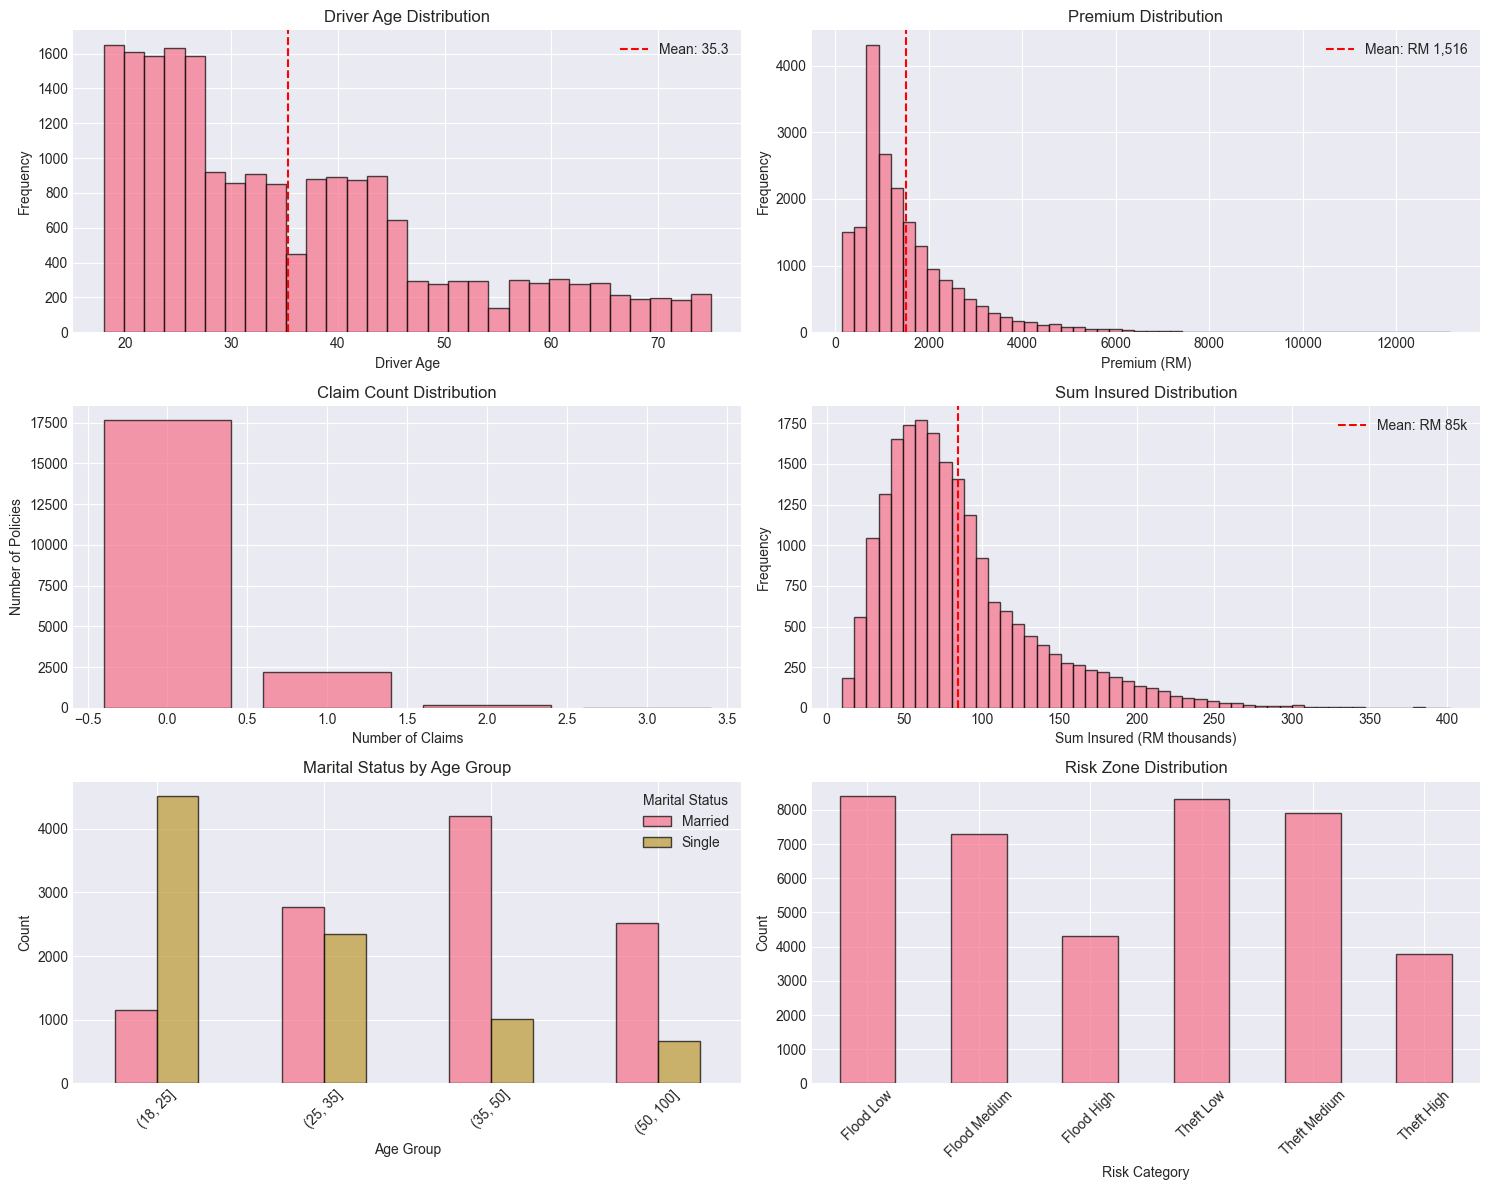

✓ Visualizations saved to images/2021_cohort_analysis.png


In [7]:
# ============================================================================
# 2021 Cohort Visualizations
# ============================================================================
fig, axes = plt.subplots(3, 2, figsize=(15, 12))

# Age distribution
axes[0, 0].hist(df_2021['driver_age'], bins=30, edgecolor='black', alpha=0.7)
axes[0, 0].axvline(df_2021['driver_age'].mean(), color='red', linestyle='--', label=f'Mean: {df_2021["driver_age"].mean():.1f}')
axes[0, 0].set_xlabel('Driver Age')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Driver Age Distribution')
axes[0, 0].legend()

# Premium distribution
axes[0, 1].hist(df_2021['policy_premium'], bins=50, edgecolor='black', alpha=0.7)
axes[0, 1].axvline(df_2021['policy_premium'].mean(), color='red', linestyle='--',
                   label=f'Mean: RM {df_2021["policy_premium"].mean():,.0f}')
axes[0, 1].set_xlabel('Premium (RM)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Premium Distribution')
axes[0, 1].legend()

# Claim count distribution
claim_dist = df_2021['claim_count'].value_counts().sort_index()
axes[1, 0].bar(claim_dist.index, claim_dist.values, edgecolor='black', alpha=0.7)
axes[1, 0].set_xlabel('Number of Claims')
axes[1, 0].set_ylabel('Number of Policies')
axes[1, 0].set_title('Claim Count Distribution')

# Sum insured distribution
axes[1, 1].hist(df_2021['sum_insured']/1000, bins=50, edgecolor='black', alpha=0.7)
axes[1, 1].axvline(df_2021['sum_insured'].mean()/1000, color='red', linestyle='--',
                   label=f'Mean: RM {df_2021["sum_insured"].mean()/1000:.0f}k')
axes[1, 1].set_xlabel('Sum Insured (RM thousands)')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Sum Insured Distribution')
axes[1, 1].legend()

# Marital status by age
marital_by_age = df_2021.groupby([pd.cut(df_2021['driver_age'], bins=[18, 25, 35, 50, 100]),
                                   'marital_status']).size().unstack()
marital_by_age.plot(kind='bar', ax=axes[2, 0], edgecolor='black', alpha=0.7)
axes[2, 0].set_xlabel('Age Group')
axes[2, 0].set_ylabel('Count')
axes[2, 0].set_title('Marital Status by Age Group')
axes[2, 0].legend(title='Marital Status')
axes[2, 0].tick_params(axis='x', rotation=45)

# Risk zones
risk_data = pd.DataFrame({
    'Flood Low': (df_2021['flood_risk_zone'] == 'Low').sum(),
    'Flood Medium': (df_2021['flood_risk_zone'] == 'Medium').sum(),
    'Flood High': (df_2021['flood_risk_zone'] == 'High').sum(),
    'Theft Low': (df_2021['theft_risk_zone'] == 'Low').sum(),
    'Theft Medium': (df_2021['theft_risk_zone'] == 'Medium').sum(),
    'Theft High': (df_2021['theft_risk_zone'] == 'High').sum(),
}, index=[0]).T
risk_data.plot(kind='bar', ax=axes[2, 1], legend=False, edgecolor='black', alpha=0.7)
axes[2, 1].set_xlabel('Risk Category')
axes[2, 1].set_ylabel('Count')
axes[2, 1].set_title('Risk Zone Distribution')
axes[2, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('images/2021_cohort_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Visualizations saved to images/2021_cohort_analysis.png")

## Section 5: Year-by-Year Evolution (2021–2025) with Integrated Table Generation

For each year, the loop:
1. Generates / evolves the policy cohort (NCD progression, renewal, new entrants)
2. Calculates premiums and claims for that year
3. Immediately generates that year's rows for:
   - **TABLE 3** – Claim Frequency
   - **TABLE 4** – Claim Severity
   - **TABLE 5** – Expenses
   - **TABLE 7** – Temporal & Exposure
   - **TABLE 8** – Peril-Level Claims
   - **TABLE 10** – Trip Telemetry (EV UBI)

After the loop, all per-year lists are concatenated into the final DataFrames.

In [8]:
# ============================================================================
# Cohort Evolution Function
# ============================================================================
def evolve_cohort_to_next_year(prev_year_policies, target_year):
    """
    Evolve previous year's cohort to the next year with NCD progression.
    """
    print("="*70)
    print(f"EVOLVING COHORT TO {target_year}")
    print("="*70)

    # ====================================================================
    # Step 1: Renewal (92% retention)
    # ====================================================================
    renewal_mask = np.random.random(len(prev_year_policies)) < 0.92
    renewed = prev_year_policies[renewal_mask].copy()

    print(f"  Renewed policies: {len(renewed):,} ({len(renewed)/len(prev_year_policies)*100:.1f}%)")

    # ====================================================================
    # Step 2: Age Progression
    # ====================================================================
    renewed['driver_age'] += 1
    renewed['vehicle_age'] += 1

    # ====================================================================
    # Step 3: Sum Insured Drift (3% annual depreciation for renewals)
    # ====================================================================
    renewed['sum_insured'] = renewed['sum_insured'] * 0.97

    # ====================================================================
    # Step 4: Marital Status Transitions
    # ====================================================================
    # Young singles get married over time
    single_young = (renewed['marital_status'] == 'Single') & (renewed['driver_age'].between(25, 35))
    transition_mask = single_young & (np.random.random(len(renewed)) < 0.10)
    renewed.loc[transition_mask, 'marital_status'] = 'Married'

    # ====================================================================
    # Step 5: Location Migration (5% urban ↔ rural)
    # ====================================================================
    migration_mask = np.random.random(len(renewed)) < 0.05
    renewed.loc[migration_mask & (renewed['location'] == 'Urban'), 'location'] = 'Rural'
    renewed.loc[migration_mask & (renewed['location'] == 'Rural'), 'location'] = 'Urban'

    # Update risk zones for migrated policies
    for idx in renewed[migration_mask].index:
        if renewed.loc[idx, 'location'] == 'Urban':
            renewed.loc[idx, 'flood_risk_zone'] = np.random.choice(['Low', 'Medium', 'High'], p=[0.50, 0.35, 0.15])
            renewed.loc[idx, 'theft_risk_zone'] = np.random.choice(['Low', 'Medium', 'High'], p=[0.30, 0.45, 0.25])
        else:
            renewed.loc[idx, 'flood_risk_zone'] = np.random.choice(['Low', 'Medium', 'High'], p=[0.30, 0.40, 0.30])
            renewed.loc[idx, 'theft_risk_zone'] = np.random.choice(['Low', 'Medium', 'High'], p=[0.60, 0.30, 0.10])

    # ====================================================================
    # Step 6: NCD PROGRESSION (Critical!)
    # ====================================================================
    # If policy had claims → reset NCD to 0%
    # If policy was claim-free → advance NCD by 1 year

    had_claims = renewed['claim_count'] > 0

    # Apply exemptions based on real-world NCD rules (Windscreen, ODKFK, NCD Protector)
    ncd_reset_mask = had_claims.copy()
    
    # Product-level approximation of safe-claim probability
    # (e.g. Windscreen / ODKFK / NCD protector situations)
    safe_claim_prob = renewed['coverage_type'].map({
        'Comprehensive': 0.35,
        'TPFT': 0.20,
        'Third Party': 0.08
    }).fillna(0.20)

    safe_claim_mask = had_claims & (np.random.random(len(renewed)) < safe_claim_prob.values)
    ncd_reset_mask = had_claims & ~safe_claim_mask

    # Reset NCD for policies with at-fault/unprotected claims
    renewed.loc[ncd_reset_mask, '_years_claim_free'] = 0
    renewed.loc[ncd_reset_mask, 'ncd_pct'] = 0.0

    # Advance NCD for claim-free policies OR policies with safe claims
    renewed.loc[~ncd_reset_mask, '_years_claim_free'] += 1
    renewed.loc[~ncd_reset_mask, 'ncd_pct'] = renewed.loc[~ncd_reset_mask, '_years_claim_free'].apply(get_ncd_percentage)

    print(f"  Policies with claims (NCD reset): {ncd_reset_mask.sum():,}")
    print(f"  Claim-free / Safe claims (NCD advanced): {(~ncd_reset_mask).sum():,}")
    print(f"  NCD distribution:")
    print(renewed['ncd_pct'].value_counts().sort_index())

    # ====================================================================
    # Step 7: Update Policy Metadata
    # ====================================================================
    renewed['underwriting_year'] = target_year
    renewed['policy_id'] = [str(uuid.uuid4()) for _ in range(len(renewed))]

    # Update policy dates
    start_dates = []
    end_dates = []
    exposures = []

    for _ in range(len(renewed)):
        if np.random.random() < 0.70:
            start = datetime(target_year, 1, 1) + timedelta(days=np.random.randint(0, 60))
        else:
            start_month = np.random.randint(4, 10)
            start = datetime(target_year, start_month, np.random.randint(1, 28))

        end = start + timedelta(days=365)
        year_end = datetime(target_year, 12, 31)
        exposure = min((year_end - start).days / 365, 1.0)
        exposure = max(0.1, exposure)

        start_dates.append(start.strftime('%Y-%m-%d'))
        end_dates.append(end.strftime('%Y-%m-%d'))
        exposures.append(round(exposure, 2))

    renewed['policy_start_date'] = start_dates
    renewed['policy_end_date'] = end_dates
    renewed['exposure'] = exposures

    # ====================================================================
    # Step 8: Recalculate Premium WITH NEW NCD
    # ====================================================================
    new_premiums = []
    for idx, row in renewed.iterrows():
        # Get vehicle data
        vehicle = vehicles[vehicles['uuid'] == row['vehicle_uuid']].iloc[0]

        premium = calculate_premium(
            sum_insured=row['sum_insured'],
            engine_cc=vehicle.get('engine_capacity_cc', 1500),
            driver_age=row['driver_age'],
            driver_gender=row['driver_gender'],
            marital_status=row['marital_status'],
            location=row['location'],
            coverage_type=row['coverage_type'],
            flood_risk_zone=row['flood_risk_zone'],
            theft_risk_zone=row['theft_risk_zone'],
            vehicle_row=vehicle,
            ncd_pct=row['ncd_pct'],  # Use updated NCD
            underwriting_year=target_year
        )
        new_premiums.append(premium)

    renewed['policy_premium'] = new_premiums

    # ====================================================================
    # Step 9: Generate New Claims
    # ====================================================================
    new_claims = []
    for idx, row in renewed.iterrows():
        vehicle = vehicles[vehicles['uuid'] == row['vehicle_uuid']].iloc[0]

        claim_count, total_claim_amount, paid_amount, outstanding_reserve, incurred_amount = generate_claims(
            driver_age=row['driver_age'],
            vehicle_age=row['vehicle_age'],
            location=row['location'],
            has_aeb=vehicle.get('has_aeb', False),
            driver_gender=row['driver_gender'],
            coverage_type=row['coverage_type'],
            sum_insured=row['sum_insured'],
            body_type=vehicle.get('body_type', 'Sedan'),
            curb_weight_kg=vehicle.get('curb_weight_kg', 1500),
            exposure=row['exposure'],
            underwriting_year=target_year
        )

        new_claims.append({
            'claim_count': claim_count,
            'total_claim_amount': round(total_claim_amount, 2),
            'paid_amount': round(paid_amount, 2),
            'outstanding_reserve': round(outstanding_reserve, 2),
            'incurred_amount': round(incurred_amount, 2)
        })

    claims_df = pd.DataFrame(new_claims)
    renewed['claim_count'] = claims_df['claim_count'].values
    renewed['total_claim_amount'] = claims_df['total_claim_amount'].values
    renewed['paid_amount'] = claims_df['paid_amount'].values
    renewed['outstanding_reserve'] = claims_df['outstanding_reserve'].values
    renewed['incurred_amount'] = claims_df['incurred_amount'].values

    # ====================================================================
    # Step 10: Add New Entrants to Maintain ~20k Policies
    # ====================================================================
    current_count = len(renewed)
    target_count = 20000
    new_entrants_needed = max(0, target_count - current_count)

    if new_entrants_needed > 0:
        print(f"  Adding {new_entrants_needed:,} new entrants...")

        new_entrants = []
        for i in range(new_entrants_needed):
            # Similar to 2021 generation, but with varied NCD
            age_segment = np.random.choice(['gen_z', 'millennial', 'boomer', 'senior'],
                                          p=[0.45, 0.35, 0.15, 0.05])

            if age_segment == 'gen_z':
                driver_age = np.random.randint(18, 28)
                is_gen_z = True
            elif age_segment == 'millennial':
                driver_age = np.random.randint(28, 46)
                is_gen_z = False
            elif age_segment == 'boomer':
                driver_age = np.random.randint(46, 66)
                is_gen_z = False
            else:
                driver_age = np.random.randint(66, 76)
                is_gen_z = False

            driver_gender = np.random.choice(['M', 'F'], p=[0.55, 0.45])

            if driver_age < 25:
                marital_status = np.random.choice(['Single', 'Married'], p=[0.85, 0.15])
            elif driver_age < 35:
                marital_status = np.random.choice(['Single', 'Married'], p=[0.50, 0.50])
            else:
                marital_status = np.random.choice(['Single', 'Married'], p=[0.20, 0.80])

            vehicle_weights = get_vehicle_weights(driver_age, is_gen_z)
            vehicle_idx = np.random.choice(vehicles.index, p=vehicle_weights)
            vehicle = vehicles.loc[vehicle_idx]

            if driver_age < 30:
                vehicle_age = np.random.choice([0, 1, 2, 3], p=[0.40, 0.30, 0.20, 0.10])
            else:
                vehicle_age = np.random.choice(range(11), p=[0.10]*10 + [0.0])

            location = np.random.choice(['Urban', 'Rural'], p=[0.60, 0.40])

            if location == 'Urban':
                flood_risk_zone = np.random.choice(['Low', 'Medium', 'High'], p=[0.50, 0.35, 0.15])
                theft_risk_zone = np.random.choice(['Low', 'Medium', 'High'], p=[0.30, 0.45, 0.25])
            else:
                flood_risk_zone = np.random.choice(['Low', 'Medium', 'High'], p=[0.30, 0.40, 0.30])
                theft_risk_zone = np.random.choice(['Low', 'Medium', 'High'], p=[0.60, 0.30, 0.10])

            coverage_type = np.random.choice(['Comprehensive', 'TPFT', 'Third Party'], p=[0.72, 0.12, 0.16])

            if np.random.random() < 0.70:
                policy_start = datetime(target_year, 1, 1) + timedelta(days=np.random.randint(0, 60))
            else:
                start_month = np.random.randint(4, 10)
                policy_start = datetime(target_year, start_month, np.random.randint(1, 28))

            policy_end = policy_start + timedelta(days=365)
            year_end = datetime(target_year, 12, 31)
            exposure = min((year_end - policy_start).days / 365, 1.0)
            exposure = max(0.1, exposure)

            base_value = vehicle.get('system_power_kw', 100) * 500 + np.random.normal(20000, 10000)
            depreciation_factor = 0.88 ** vehicle_age
            sum_insured = max(10000, base_value * depreciation_factor)

            # New entrants: assign NCD based on claim history (weighted towards 0-2 years)
            years_claim_free = np.random.choice([0, 1, 2, 3, 4, 5], p=[0.40, 0.25, 0.15, 0.10, 0.05, 0.05])
            ncd_pct = get_ncd_percentage(years_claim_free)

            policy_premium = calculate_premium(
                sum_insured=sum_insured,
                engine_cc=vehicle.get('engine_capacity_cc', 1500),
                driver_age=driver_age,
                driver_gender=driver_gender,
                marital_status=marital_status,
                location=location,
                coverage_type=coverage_type,
                flood_risk_zone=flood_risk_zone,
                theft_risk_zone=theft_risk_zone,
                vehicle_row=vehicle,
                ncd_pct=ncd_pct,
                underwriting_year=target_year
            )

            claim_count, total_claim_amount, paid_amount, outstanding_reserve, incurred_amount = generate_claims(
                driver_age=driver_age,
                vehicle_age=vehicle_age,
                location=location,
                has_aeb=vehicle.get('has_aeb', False),
                driver_gender=driver_gender,
                coverage_type=coverage_type,
                sum_insured=sum_insured,
                body_type=vehicle.get('body_type', 'Sedan'),
                curb_weight_kg=vehicle.get('curb_weight_kg', 1500),
                exposure=exposure,
                underwriting_year=target_year
            )

            # Generate unique policyholder ID
            ph_id = f"PH{len(prev_year_policies) + i + 1:06d}"

            policy = {
                'policy_id': str(uuid.uuid4()),
                'underwriting_year': target_year,
                'coverage_type': coverage_type,
                'vehicle_id': vehicle['vehicle_id'],
                'vehicle_uuid': vehicle['uuid'],
                'vehicle_age': vehicle_age,
                'driver_age': driver_age,
                'driver_gender': driver_gender,
                'location': location,
                'sum_insured': round(sum_insured, 2),
                'exposure': round(exposure, 2),
                'claim_count': claim_count,
                'total_claim_amount': round(total_claim_amount, 2),
                'policy_premium': policy_premium,
                'paid_amount': round(paid_amount, 2),
                'outstanding_reserve': round(outstanding_reserve, 2),
                'incurred_amount': round(incurred_amount, 2),
                'marital_status': marital_status,
                'flood_risk_zone': flood_risk_zone,
                'theft_risk_zone': theft_risk_zone,
                'ncd_pct': ncd_pct,
                'policy_start_date': policy_start.strftime('%Y-%m-%d'),
                'policy_end_date': policy_end.strftime('%Y-%m-%d'),
                '_policyholder_id': ph_id,
                '_is_gen_z': is_gen_z,
                '_years_claim_free': years_claim_free
            }

            new_entrants.append(policy)

        new_entrants_df = pd.DataFrame(new_entrants)
        cohort = pd.concat([renewed, new_entrants_df], ignore_index=True)
    else:
        cohort = renewed

    print(f"\n  Final cohort size: {len(cohort):,}")
    print(f"  Claim frequency: {(cohort['claim_count'] > 0).mean()*100:.2f}%")
    print(f"  Average premium: RM {cohort['policy_premium'].mean():,.2f}")

    return cohort

print("✓ Cohort evolution function ready")

✓ Cohort evolution function ready


In [ ]:
# ============================================================================
# Execute Year-by-Year Evolution with Per-Year Table Generation
# ============================================================================
np.random.seed(42)

# ====================================================================
# Helper Functions (used inside the loop)
# ====================================================================
def assign_claim_peril(row):
    """Assign representative claim peril based on policy product."""
    return sample_claim_peril(row['coverage_type'])

def is_festive_period(date_str):
    """Check if date falls in festive period (Q4/Q1 for major festivals)"""
    month = int(date_str.split('-')[1])
    return month in [10, 11, 12, 1, 2]

def is_monsoon_season(date_str, location):
    """Check if date falls in northeast monsoon (Nov-Feb for East Coast)"""
    month = int(date_str.split('-')[1])
    if location == 'Rural':  # Proxy for coastal/monsoon-prone areas
        return month in [11, 12, 1, 2]
    return False

# ====================================================================
# Per-Year Accumulators
# ====================================================================
yearly_dfs    = {}          # policy DataFrames by year
all_freq_records    = []    # TABLE 3 – Claim Frequency
all_sev_records     = []    # TABLE 4 – Claim Severity
all_expense_records = []    # TABLE 5 – Expenses
all_temporal_records= []    # TABLE 7 – Temporal Exposure
all_claim_records   = []    # TABLE 8 – Peril-Level Claims
all_trip_records    = []    # TABLE 10 – Trip Telemetry

# ====================================================================
# Main Year-by-Year Loop
# ====================================================================
prev_df = None

for year in [2021, 2022, 2023, 2024, 2025]:
    print("\n" + "="*70)
    print(f"PROCESSING YEAR {year}")
    print("="*70)

    # ----------------------------------------------------------------
    # Step 1: Get / Generate this year's policy cohort
    # ----------------------------------------------------------------
    if year == 2021:
        year_df = df_2021.copy()
        print(f"  Using pre-generated 2021 cohort: {len(year_df):,} policies")
    else:
        year_df = evolve_cohort_to_next_year(prev_df, year)

    # ----------------------------------------------------------------
    # Step 2: Enrich with derived columns (peril, bands, flags)
    # ----------------------------------------------------------------
    year_df = year_df.copy()

    year_df['claim_peril'] = year_df.apply(assign_claim_peril, axis=1)

    year_df['driver_age_band'] = pd.cut(
        year_df['driver_age'],
        bins=[0, 25, 35, 50, 65, 100],
        labels=['18-24', '25-34', '35-49', '50-64', '65+']
    )
    year_df['vehicle_age_band'] = pd.cut(
        year_df['vehicle_age'],
        bins=[-1, 2, 5, 10, 100],
        labels=['0-2', '3-5', '6-10', '10+']
    )
    year_df['sum_insured_band'] = pd.cut(
        year_df['sum_insured'],
        bins=[0, 30000, 60000, 100000, 200000, 1000000],
        labels=['<30k', '30-60k', '60-100k', '100-200k', '200k+']
    )
    year_df['is_festive_period'] = year_df['policy_start_date'].apply(is_festive_period)
    year_df['is_northeast_monsoon'] = year_df.apply(
        lambda row: is_monsoon_season(row['policy_start_date'], row['location']), axis=1
    )

    # Store enriched df; use as prev_df for next year's evolution
    yearly_dfs[year] = year_df
    prev_df = year_df

    # ----------------------------------------------------------------
    # Step 3: TABLE 3 – Claim Frequency rows for this year
    # ----------------------------------------------------------------
    freq_groupby_cols = [
        'coverage_type', 'vehicle_uuid', 'vehicle_age_band',
        'driver_age_band', 'location', 'claim_peril'
    ]
    year_freq = year_df.groupby(freq_groupby_cols, dropna=False).agg({
        'claim_count': 'sum',
        'exposure': 'sum',
        'is_festive_period': lambda x: x.mean() > 0.5,
        'is_northeast_monsoon': lambda x: x.mean() > 0.5
    }).reset_index()
    year_freq.rename(columns={'claim_count': 'total_claims', 'exposure': 'total_exposure'}, inplace=True)
    year_freq.insert(0, 'frequency_id', [str(uuid.uuid4()) for _ in range(len(year_freq))])
    year_freq['underwriting_year'] = year
    all_freq_records.append(year_freq)
    print(f"  TABLE 3 (Claim Frequency):   {len(year_freq):,} rows")

    # ----------------------------------------------------------------
    # Step 4: TABLE 4 – Claim Severity rows for this year
    # ----------------------------------------------------------------
    claims_only = year_df[year_df['claim_count'] > 0].copy()
    if len(claims_only) > 0:
        sev_groupby_cols = [
            'coverage_type', 'vehicle_uuid', 'vehicle_age_band',
            'sum_insured_band', 'claim_peril'
        ]
        year_sev = claims_only.groupby(sev_groupby_cols, dropna=False).agg({
            'claim_count': 'sum',
            'total_claim_amount': 'sum'
        }).reset_index()
        year_sev.insert(0, 'severity_id', [str(uuid.uuid4()) for _ in range(len(year_sev))])
        year_sev['large_loss_flag'] = year_sev['total_claim_amount'] / year_sev['claim_count'] > 50000
        year_sev['capped_claim_amount'] = year_sev.apply(
            lambda row: min(row['total_claim_amount'] / row['claim_count'], 50000) * row['claim_count'],
            axis=1
        ).round(2)
        year_sev['underwriting_year'] = year
        all_sev_records.append(year_sev)
        print(f"  TABLE 4 (Claim Severity):    {len(year_sev):,} rows")

    # ----------------------------------------------------------------
    # Step 5: TABLE 5 – Expense row for this year
    # ----------------------------------------------------------------
    gwp = year_df['policy_premium'].sum()
    gep = gwp * year_df['exposure'].mean()
    all_expense_records.append({
        'expense_id': str(uuid.uuid4()),
        'calendar_year': year,
        'commission_rate': round(0.12 + (year - 2021) * 0.0075, 4),
        'fixed_expense_per_policy': round(150 + (year - 2021) * 12, 2),
        'inflation_index': round(100 * (1.025 ** (year - 2021)), 2),
        'trending_factor': round(1.000 + (year - 2021) * 0.015, 4),
        'gwp_myr': round(gwp, 2),
        'gep_myr': round(gep, 2)
    })
    print(f"  TABLE 5 (Expense):           GWP=RM{gwp:,.0f}, GEP=RM{gep:,.0f}")

    # ----------------------------------------------------------------
    # Step 6: TABLE 7 – Temporal Exposure rows for this year
    # ----------------------------------------------------------------
    year_temporal = []
    for idx, policy in year_df.iterrows():
        policy_start = datetime.strptime(policy['policy_start_date'], '%Y-%m-%d')
        policy_end   = datetime.strptime(policy['policy_end_date'],   '%Y-%m-%d')
        quarters = [
            (datetime(year, 1, 1),  datetime(year, 3, 31),  1),
            (datetime(year, 4, 1),  datetime(year, 6, 30),  2),
            (datetime(year, 7, 1),  datetime(year, 9, 30),  3),
            (datetime(year, 10, 1), datetime(year, 12, 31), 4),
        ]
        for q_start, q_end, quarter in quarters:
            overlap_start = max(policy_start, q_start)
            overlap_end   = min(policy_end,   q_end)
            if overlap_start <= overlap_end:
                days_in_quarter = (overlap_end - overlap_start).days + 1
                year_temporal.append({
                    'temporal_id': str(uuid.uuid4()),
                    'policy_id': policy['policy_id'],
                    'accident_year': year,
                    'accident_quarter': quarter,
                    'exposure_vehicle_years': round(days_in_quarter / 365, 4),
                    'is_festive_period': quarter in [4, 1],
                    'is_northeast_monsoon': quarter in [4, 1] and policy['location'] == 'Rural',
                    'exposure_start_date': overlap_start.strftime('%Y-%m-%d'),
                    'exposure_end_date':   overlap_end.strftime('%Y-%m-%d'),
                    'policy_start_date': policy_start.strftime('%Y-%m-%d'),
                    'policy_end_date':   policy_end.strftime('%Y-%m-%d')
                })
    all_temporal_records.extend(year_temporal)
    print(f"  TABLE 7 (Temporal Exposure): {len(year_temporal):,} rows")

    # ----------------------------------------------------------------
    # Step 7: TABLE 8 – Peril-Level Claims rows for this year
    # ----------------------------------------------------------------
    policies_with_claims = year_df[year_df['claim_count'] > 0].copy()
    year_claims = []
    for idx, policy in policies_with_claims.iterrows():
        policy_start = datetime.strptime(policy['policy_start_date'], '%Y-%m-%d')
        policy_end   = datetime.strptime(policy['policy_end_date'],   '%Y-%m-%d')
        num_claims = int(policy['claim_count'])
        if num_claims == 1:
            claim_amounts = [policy['total_claim_amount']]
        else:
            proportions   = np.random.dirichlet([1] * num_claims)
            claim_amounts = [policy['total_claim_amount'] * p for p in proportions]

        for i in range(num_claims):
            peril = sample_claim_peril(policy['coverage_type'])

            days_in_policy = (policy_end - policy_start).days
            loss_date       = policy_start + timedelta(days=np.random.randint(0, max(1, days_in_policy)))
            intimation_date = loss_date    + timedelta(days=np.random.randint(1, 15))

            settlement_ratio = {2021: 1.00, 2022: 0.80, 2023: 0.60, 2024: 0.40, 2025: 0.30}
            is_settled = np.random.random() < settlement_ratio.get(year, 1.0)
            if is_settled:
                settlement_date = loss_date + timedelta(days=np.random.randint(30, 181))
            else:
                settlement_date = None

            claim_amount = claim_amounts[i]
            if is_settled:
                paid, outstanding = claim_amount, 0.0
            else:
                paid_ratio = np.random.uniform(0.3, 0.7)
                paid       = claim_amount * paid_ratio
                outstanding= claim_amount * (1 - paid_ratio)

            incurred = paid + outstanding
            year_claims.append({
                'claim_id': str(uuid.uuid4()),
                'policy_id': policy['policy_id'],
                'claim_peril': peril,
                'loss_date': loss_date.strftime('%Y-%m-%d'),
                'intimation_date': intimation_date.strftime('%Y-%m-%d'),
                'settlement_date': settlement_date.strftime('%Y-%m-%d') if settlement_date else None,
                'paid_amount': round(paid, 2),
                'outstanding_reserve': round(outstanding, 2),
                'large_loss_flag': incurred > 50000,
                'capped_claim_amount': round(min(incurred, 50000), 2)
            })
    all_claim_records.extend(year_claims)
    print(f"  TABLE 8 (Peril Claims):      {len(year_claims):,} rows")

    # ----------------------------------------------------------------
    # Step 8: TABLE 10 – Trip Telemetry rows for this year (EV only)
    # ----------------------------------------------------------------
    year_ev = year_df.merge(vehicles[['uuid', 'fuel_type']],
                            left_on='vehicle_uuid', right_on='uuid', how='left')
    year_ev = year_ev[year_ev['fuel_type'] == 'Electric'].copy()
    year_trips = []
    trips_per_policy = 50

    for idx, policy in year_ev.iterrows():
        policy_start = datetime.strptime(policy['policy_start_date'], '%Y-%m-%d')
        policy_end   = datetime.strptime(policy['policy_end_date'],   '%Y-%m-%d')
        num_trips = int(trips_per_policy * policy['exposure'])

        for _ in range(num_trips):
            days_in_policy = (policy_end - policy_start).days
            trip_date   = policy_start + timedelta(days=np.random.randint(0, max(1, days_in_policy)))
            hour_weights = np.array([0.5]*6 + [3.0, 4.0, 3.0] + [1.0]*3 + [1.5]*2 +
                                    [1.0]*3 + [3.0, 4.0, 3.0] + [1.5]*4)
            hour_weights /= hour_weights.sum()
            trip_hour   = np.random.choice(range(24), p=hour_weights)
            trip_minute = np.random.randint(0, 60)
            trip_start  = trip_date.replace(hour=trip_hour, minute=trip_minute, second=0)
            trip_dur_min= int(max(5, np.random.gamma(2, 15)))
            trip_end    = trip_start + timedelta(minutes=trip_dur_min)

            distance_km     = max(1, np.random.gamma(2, 15))
            avg_speed_kph   = min(110, max(20, distance_km / trip_dur_min * 60))
            max_speed_kph   = min(130, avg_speed_kph * np.random.uniform(1.1, 1.4))
            speed_variance  = np.random.gamma(2, 5)

            if policy['driver_age'] < 25:
                hard_accel = np.random.poisson(distance_km * 0.15)
                hard_brake = np.random.poisson(distance_km * 0.12)
            elif policy['driver_age'] < 50:
                hard_accel = np.random.poisson(distance_km * 0.08)
                hard_brake = np.random.poisson(distance_km * 0.07)
            else:
                hard_accel = np.random.poisson(distance_km * 0.05)
                hard_brake = np.random.poisson(distance_km * 0.04)

            efficiency_wh_per_km = 180 * np.random.uniform(0.85, 1.15)
            energy_used_kwh      = (distance_km * efficiency_wh_per_km) / 1000
            regen_ratio          = np.random.beta(2, 5)
            regen_energy_kwh     = energy_used_kwh * regen_ratio
            hvac_ratio = (np.random.beta(2, 3) * 0.3
                          if trip_date.month in [12, 1, 2, 6, 7, 8]
                          else np.random.beta(2, 5) * 0.15)
            start_soc_pct = np.random.uniform(20, 95)
            end_soc_pct   = max(5, start_soc_pct - (energy_used_kwh / 60) * 100)
            stop_count    = int(max(0, np.random.poisson(distance_km * 0.3)))

            urban_ratio   = (np.random.beta(5, 2) if policy['location'] == 'Urban'
                             else np.random.beta(2, 5))

            year_trips.append({
                'trip_id': str(uuid.uuid4()),
                'driver_id': policy['policy_id'],
                'trip_start_time': trip_start.strftime('%Y-%m-%d %H:%M:%S'),
                'trip_end_time':   trip_end.strftime('%Y-%m-%d %H:%M:%S'),
                'trip_duration_min': trip_dur_min,
                'distance_km': round(distance_km, 2),
                'avg_speed_kph': round(avg_speed_kph, 1),
                'max_speed_kph': round(max_speed_kph, 1),
                'speed_variance': round(speed_variance, 2),
                'hard_accel_count': hard_accel,
                'hard_brake_count': hard_brake,
                'accel_variance': round(np.random.gamma(1.5, 0.3), 3),
                'energy_used_kwh': round(energy_used_kwh, 2),
                'efficiency_wh_per_km': round(efficiency_wh_per_km, 1),
                'regen_energy_kwh': round(regen_energy_kwh, 2),
                'regen_ratio': round(regen_ratio, 3),
                'hvac_energy_ratio': round(hvac_ratio, 3),
                'start_soc_pct': round(start_soc_pct, 1),
                'end_soc_pct': round(end_soc_pct, 1),
                'elevation_gain_m': int(max(0, np.random.gamma(1.5, 50))),
                'stop_count': stop_count,
                'stops_per_km': round(stop_count / distance_km if distance_km > 0 else 0, 2),
                'route_repeat_ratio': round(np.random.beta(3, 2), 3),
                'trip_radius_km': round(distance_km * np.random.uniform(0.3, 0.7), 2),
                'urban_ratio': round(urban_ratio, 3),
                'highway_ratio': round(1 - urban_ratio, 3),
                'is_night_trip': 19 <= trip_hour or trip_hour < 6,
                'is_midnight_trip': 0 <= trip_hour < 4,
                'is_weekend': trip_date.weekday() >= 5,
                'weather_severity': np.random.choice([0, 1, 2], p=[0.70, 0.25, 0.05]),
                'cold_start': trip_date.month in [12, 1, 2] and trip_hour < 8
            })
    all_trip_records.extend(year_trips)
    print(f"  TABLE 10 (Trip Telemetry):   {len(year_trips):,} rows (EV only)")

# ====================================================================
# Combine All Years → final_dataset
# ====================================================================
final_dataset = pd.concat(list(yearly_dfs.values()), ignore_index=True)

print("\n" + "="*70)
print("FINAL COMBINED DATASET SUMMARY")
print("="*70)
print(f"\nTotal policies across all years: {len(final_dataset):,}")
print(f"\nPolicies by year:")
print(final_dataset['underwriting_year'].value_counts().sort_index())
print(f"\nAverage NCD by year:")
avg_ncd = final_dataset.groupby('underwriting_year')['ncd_pct'].mean()
for year, ncd in avg_ncd.items():
    print(f"  {year}: {ncd*100:.2f}%")
print(f"\nClaim statistics by year:")
claim_stats = final_dataset.groupby('underwriting_year').agg({
    'claim_count': ['sum', lambda x: (x > 0).mean()],
    'incurred_amount': 'sum',
    'policy_premium': 'sum'
})
claim_stats.columns = ['Total Claims', 'Claim Frequency', 'Total Incurred', 'Total Premium']
claim_stats['Loss Ratio'] = claim_stats['Total Incurred'] / claim_stats['Total Premium']
print(claim_stats)
print(f"\nOverall statistics:")
print(f"  Total GWP:     RM {final_dataset['policy_premium'].sum():,.2f}")
print(f"  Total Incurred:RM {final_dataset['incurred_amount'].sum():,.2f}")
print(f"  Overall Loss Ratio: {final_dataset['incurred_amount'].sum() / final_dataset['policy_premium'].sum():.2%}")

# ====================================================================
# Consolidate All Per-Year Tables
# ====================================================================
df_claim_freq = pd.concat(all_freq_records, ignore_index=True)
df_claim_freq = df_claim_freq.groupby(['coverage_type', 'vehicle_uuid', 'vehicle_age_band', 'driver_age_band', 'location', 'claim_peril'], dropna=False).agg({'total_claims': 'sum', 'total_exposure': 'sum', 'is_festive_period': 'any', 'is_northeast_monsoon': 'any'}).reset_index()
df_claim_freq.insert(0, 'frequency_id', [str(uuid.uuid4()) for _ in range(len(df_claim_freq))])

df_claim_sev  = pd.concat(all_sev_records,  ignore_index=True)
df_claim_sev = df_claim_sev.groupby(['coverage_type', 'vehicle_uuid', 'vehicle_age_band', 'sum_insured_band', 'claim_peril'], dropna=False).agg({'claim_count': 'sum', 'total_claim_amount': 'sum'}).reset_index()
df_claim_sev['large_loss_flag'] = (df_claim_sev['total_claim_amount'] / df_claim_sev['claim_count']) > 50000
df_claim_sev['capped_claim_amount'] = df_claim_sev.apply(lambda row: min(row['total_claim_amount'] / row['claim_count'], 50000) * row['claim_count'] if row['claim_count'] > 0 else 0, axis=1).round(2)
df_claim_sev.insert(0, 'severity_id', [str(uuid.uuid4()) for _ in range(len(df_claim_sev))])

df_expenses   = pd.DataFrame(all_expense_records)
df_temporal   = pd.DataFrame(all_temporal_records)
df_claims     = pd.DataFrame(all_claim_records)
df_trips      = pd.DataFrame(all_trip_records)

print(f"\n{'='*70}")
print("TABLE GENERATION SUMMARY (all years combined)")
print(f"{'='*70}")
print(f"  TABLE 3  (Claim Frequency):    {len(df_claim_freq):>8,} rows")
print(f"  TABLE 4  (Claim Severity):     {len(df_claim_sev):>8,} rows")
print(f"  TABLE 5  (Expenses):           {len(df_expenses):>8,} rows")
print(f"  TABLE 7  (Temporal Exposure):  {len(df_temporal):>8,} rows")
print(f"  TABLE 8  (Peril Claims):       {len(df_claims):>8,} rows")
print(f"  TABLE 10 (Trip Telemetry):     {len(df_trips):>8,} rows")
print("\n✓ Year-by-year evolution and per-year table generation complete")


PROCESSING YEAR 2021
  Using pre-generated 2021 cohort: 20,000 policies
  TABLE 3 (Claim Frequency):   14,505 rows
  TABLE 4 (Claim Severity):    1,870 rows
  TABLE 5 (Expense):           GWP=RM30,318,122, GEP=RM23,943,964
  TABLE 7 (Temporal Exposure): 70,738 rows
  TABLE 8 (Peril Claims):      2,557 rows
  TABLE 10 (Trip Telemetry):   206,379 rows (EV only)

PROCESSING YEAR 2022
EVOLVING COHORT TO 2022
  Renewed policies: 18,358 (91.8%)
  Policies with claims (NCD reset): 1,488
  Claim-free / Safe claims (NCD advanced): 16,870
  NCD distribution:
ncd_pct
0.00     1488
0.25    16870
Name: count, dtype: int64
  Adding 1,642 new entrants...

  Final cohort size: 20,000
  Claim frequency: 12.16%
  Average premium: RM 1,353.52
  TABLE 3 (Claim Frequency):   14,898 rows
  TABLE 4 (Claim Severity):    1,973 rows
  TABLE 5 (Expense):           GWP=RM27,070,410, GEP=RM21,452,068
  TABLE 7 (Temporal Exposure): 70,961 rows
  TABLE 8 (Peril Claims):      2,632 rows
  TABLE 10 (Trip Telemetry): 

## Section 6: Statistical Validation

### Part A: Core Validation (8 tests)
- Correlation analysis, premium reasonableness, NCD impact

### Part B: Enhanced Statistical Tests (NEW)
- **Distribution Fit Tests**: KS test for premium (log-normal), Gamma fit for severity
- **NCD Distribution by Year**: Verify progression from 0% to 55% over time
- **Loss Ratio by Segment**: Premium vs claims ratio by coverage/age/location
- **Severity Percentile Validation**: 95th percentile targets by coverage type
- **Longitudinal Consistency**: Same policyholder tracking across years
- **NCD Impact Visualization**: Premium reduction curve by NCD tier
- **Gen Z vs Non-Gen Z Comparison**: Claim rates, premiums, NCD distribution

DATASET VALIDATION

                                   Test                     Value                     Expected  Pass
     Premium vs Sum Insured Correlation                     0.762                        > 0.5  True
           Young Driver Premium Loading                     1.91x                       > 1.2x  True
                Overall Claim Frequency                    12.41%                       10-20%  True
          NCD Progression (2021 < 2025)              0.0% → 35.9%                   Increasing  True
                     Overall Loss Ratio                    64.93%                       50-80%  True
                  Urban Premium > Rural                     1.30x                       > 1.1x  True
    Comprehensive Premium > Third Party                     2.51x                       > 1.8x  True
               NCD Discount (0% vs 55%)                     20.4%                       20-45%  True
Comprehensive Premium Trend (2021→2025) RM1,805 → RM1,568 (0.87x) Mild 

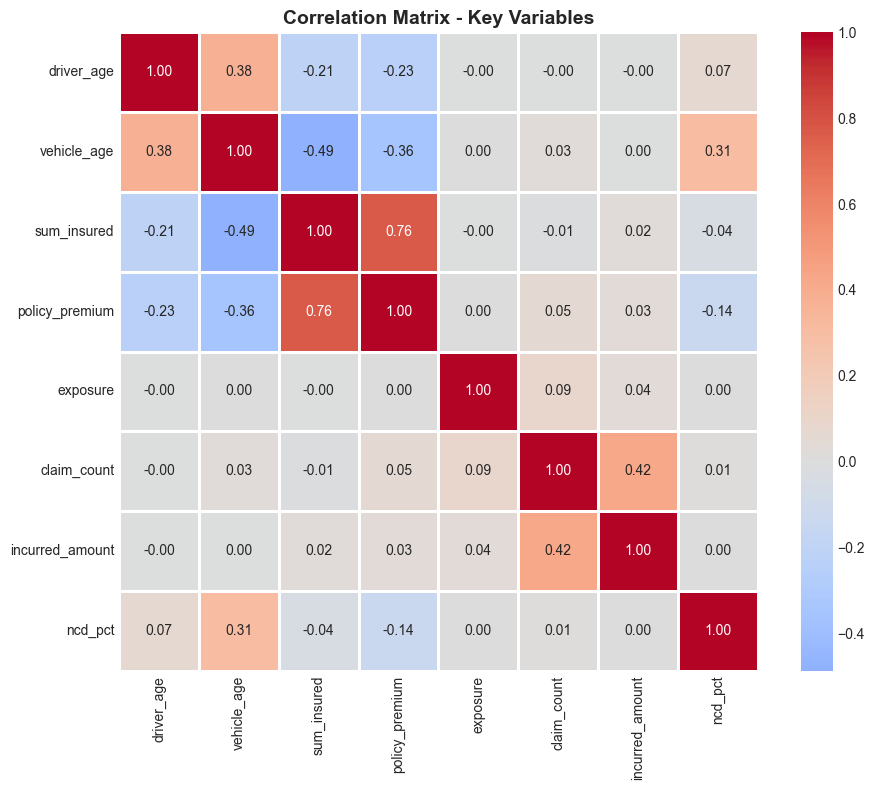


✓ Validation complete - correlation heatmap saved


In [10]:
# ============================================================================
# Statistical Validation
# ============================================================================
print("="*70)
print("DATASET VALIDATION")
print("="*70)

validation_results = []

# ====================================================================
# Test 1: Premium vs Sum Insured Correlation
# ====================================================================
corr = final_dataset['policy_premium'].corr(final_dataset['sum_insured'])
validation_results.append({
    'Test': 'Premium vs Sum Insured Correlation',
    'Value': f"{corr:.3f}",
    'Expected': '> 0.5',
    'Pass': corr > 0.5
})

# ====================================================================
# Test 2: Young Driver Premium Loading
# ====================================================================
young_avg = final_dataset[final_dataset['driver_age'] < 25]['policy_premium'].mean()
mature_avg = final_dataset[final_dataset['driver_age'].between(30, 50)]['policy_premium'].mean()
loading = young_avg / mature_avg
validation_results.append({
    'Test': 'Young Driver Premium Loading',
    'Value': f"{loading:.2f}x",
    'Expected': '> 1.2x',
    'Pass': loading > 1.2
})

# ====================================================================
# Test 3: Claim Frequency Range
# ====================================================================
claim_freq = (final_dataset['claim_count'] > 0).mean()
validation_results.append({
    'Test': 'Overall Claim Frequency',
    'Value': f"{claim_freq*100:.2f}%",
    'Expected': '10-20%',
    'Pass': 0.10 <= claim_freq <= 0.20
})

# ====================================================================
# Test 4: NCD Progression
# ====================================================================
# Check that average NCD increases over years
ncd_2021 = final_dataset[final_dataset['underwriting_year'] == 2021]['ncd_pct'].mean()
ncd_2025 = final_dataset[final_dataset['underwriting_year'] == 2025]['ncd_pct'].mean()
validation_results.append({
    'Test': 'NCD Progression (2021 < 2025)',
    'Value': f"{ncd_2021*100:.1f}% → {ncd_2025*100:.1f}%",
    'Expected': 'Increasing',
    'Pass': ncd_2025 > ncd_2021
})

# ====================================================================
# Test 5: Loss Ratio Range
# ====================================================================
loss_ratio = final_dataset['incurred_amount'].sum() / final_dataset['policy_premium'].sum()
validation_results.append({
    'Test': 'Overall Loss Ratio',
    'Value': f"{loss_ratio:.2%}",
    'Expected': '50-80%',
    'Pass': 0.50 <= loss_ratio <= 0.80
})

# ====================================================================
# Test 6: Urban vs Rural Premium
# ====================================================================
urban_avg = final_dataset[final_dataset['location'] == 'Urban']['policy_premium'].mean()
rural_avg = final_dataset[final_dataset['location'] == 'Rural']['policy_premium'].mean()
urban_ratio = urban_avg / rural_avg
validation_results.append({
    'Test': 'Urban Premium > Rural',
    'Value': f"{urban_ratio:.2f}x",
    'Expected': '> 1.1x',
    'Pass': urban_ratio > 1.1
})

# ====================================================================
# Test 7: Comprehensive vs Third Party Premium
# ====================================================================
comp_avg = final_dataset[final_dataset['coverage_type'] == 'Comprehensive']['policy_premium'].mean()
tp_avg = final_dataset[final_dataset['coverage_type'] == 'Third Party']['policy_premium'].mean()
comp_ratio = comp_avg / tp_avg
validation_results.append({
    'Test': 'Comprehensive Premium > Third Party',
    'Value': f"{comp_ratio:.2f}x",
    'Expected': '> 1.8x',
    'Pass': comp_ratio > 1.8
})

# ====================================================================
# Test 8: NCD Impact on Premium
# ====================================================================
no_ncd_avg = final_dataset[final_dataset['ncd_pct'] == 0.0]['policy_premium'].mean()
max_ncd_avg = final_dataset[final_dataset['ncd_pct'] == 0.55]['policy_premium'].mean()
ncd_discount = 1 - (max_ncd_avg / no_ncd_avg)
validation_results.append({
    'Test': 'NCD Discount (0% vs 55%)',
    'Value': f"{ncd_discount*100:.1f}%",
    'Expected': '20-45%',
    'Pass': 0.20 <= ncd_discount <= 0.45
})


# ====================================================================
# Test 9: Comprehensive Premium Trend Stability
# ====================================================================
comp_2021_avg = final_dataset[
    (final_dataset['underwriting_year'] == 2021) &
    (final_dataset['coverage_type'] == 'Comprehensive')
]['policy_premium'].mean()

comp_2025_avg = final_dataset[
    (final_dataset['underwriting_year'] == 2025) &
    (final_dataset['coverage_type'] == 'Comprehensive')
]['policy_premium'].mean()

comp_trend_ratio = comp_2025_avg / comp_2021_avg

validation_results.append({
    'Test': 'Comprehensive Premium Trend (2021→2025)',
    'Value': f"RM{comp_2021_avg:,.0f} → RM{comp_2025_avg:,.0f} ({comp_trend_ratio:.2f}x)",
    'Expected': 'Mild softening (0.80x–0.99x)',
    'Pass': 0.80 <= comp_trend_ratio < 1.00
})

# Display results
validation_df = pd.DataFrame(validation_results)
print("\n" + validation_df.to_string(index=False))

all_pass = validation_df['Pass'].all()
print("\n" + "="*70)
if all_pass:
    print("✓✓✓ ALL VALIDATION TESTS PASSED ✓✓✓")
else:
    print("⚠ SOME VALIDATION TESTS FAILED - REVIEW ABOVE")
print("="*70)

# ====================================================================
# Correlation Heatmap
# ====================================================================
numeric_cols = ['driver_age', 'vehicle_age', 'sum_insured', 'policy_premium',
                'exposure', 'claim_count', 'incurred_amount', 'ncd_pct']

correlation_matrix = final_dataset[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=1)
plt.title('Correlation Matrix - Key Variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('images/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Validation complete - correlation heatmap saved")

### Part B: Enhanced Statistical Tests

ENHANCED STATISTICAL VALIDATION

1. PREMIUM DISTRIBUTION FIT TEST (Log-Normal)
   KS Statistic: 0.0765
   P-value: 0.0000e+00
   Note: For N=100,000, KS test is very sensitive.
   KS stat < 0.1 indicates approximate log-normal shape: ✓ PASS

2. CLAIM SEVERITY DISTRIBUTION FIT (Gamma)
------------------------------------------------------------
   Comprehensive: shape=0.55, scale=11354, KS=0.0621
   TPFT: shape=0.50, scale=23000, KS=0.0520
   Third Party: shape=0.41, scale=28859, KS=0.0654

3. NCD DISTRIBUTION BY YEAR
------------------------------------------------------------
   2021: Avg NCD=0.0% | NCD=0%: 100.0% | NCD=55%: 0.0%
   2022: Avg NCD=22.6% | NCD=0%: 10.9% | NCD=55%: 0.4%
   2023: Avg NCD=26.8% | NCD=0%: 10.9% | NCD=55%: 1.1%
   2024: Avg NCD=32.3% | NCD=0%: 10.9% | NCD=55%: 2.3%
   2025: Avg NCD=35.9% | NCD=0%: 11.1% | NCD=55%: 4.0%


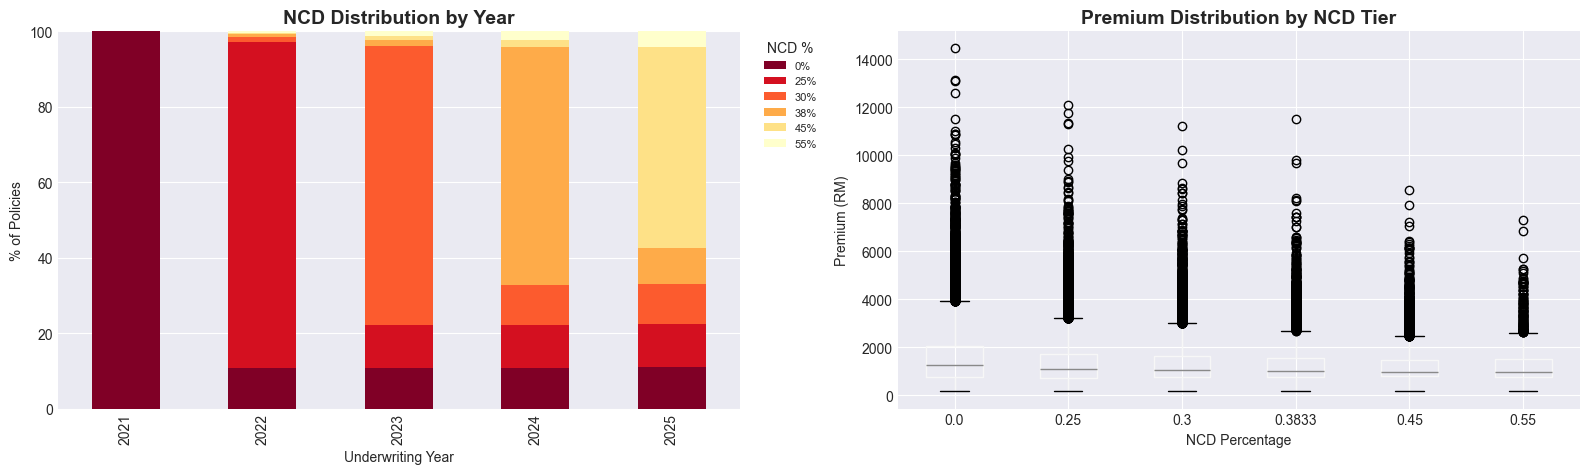


4. LOSS RATIO BY SEGMENT
------------------------------------------------------------
   By Coverage Type:
     Comprehensive: LR=54.62% (n=71,923)
     TPFT  : LR=115.34% (n=12,191)
     Third Party: LR=125.98% (n=15,886)
   By Age Group:
     Gen Z (18-27)  : LR=54.47% (n=34,193)
     Prime (28-50)  : LR=70.90% (n=48,642)
     Senior (51+)   : LR=80.81% (n=17,165)
   By Location:
     Urban   : LR=65.15%
     Rural   : LR=64.45%

5. SEVERITY PERCENTILE VALIDATION
------------------------------------------------------------
   Comprehensive: Mean=RM6,250 (target: RM2,500-7,000) ✓
                  P95=RM24,830 (target: RM12,000-50,000) ✓
   TPFT: Mean=RM11,607 (target: RM3,500-12,000) ✓
         P95=RM44,255 (target: RM15,000-90,000) ✓
   Third Party: Mean=RM11,840 (target: RM4,000-40,000) ✓
                P95=RM47,029 (target: RM15,000-600,000) ✓

6. LONGITUDINAL CONSISTENCY
------------------------------------------------------------
   Unique policyholders: 21,642
   Policyholder

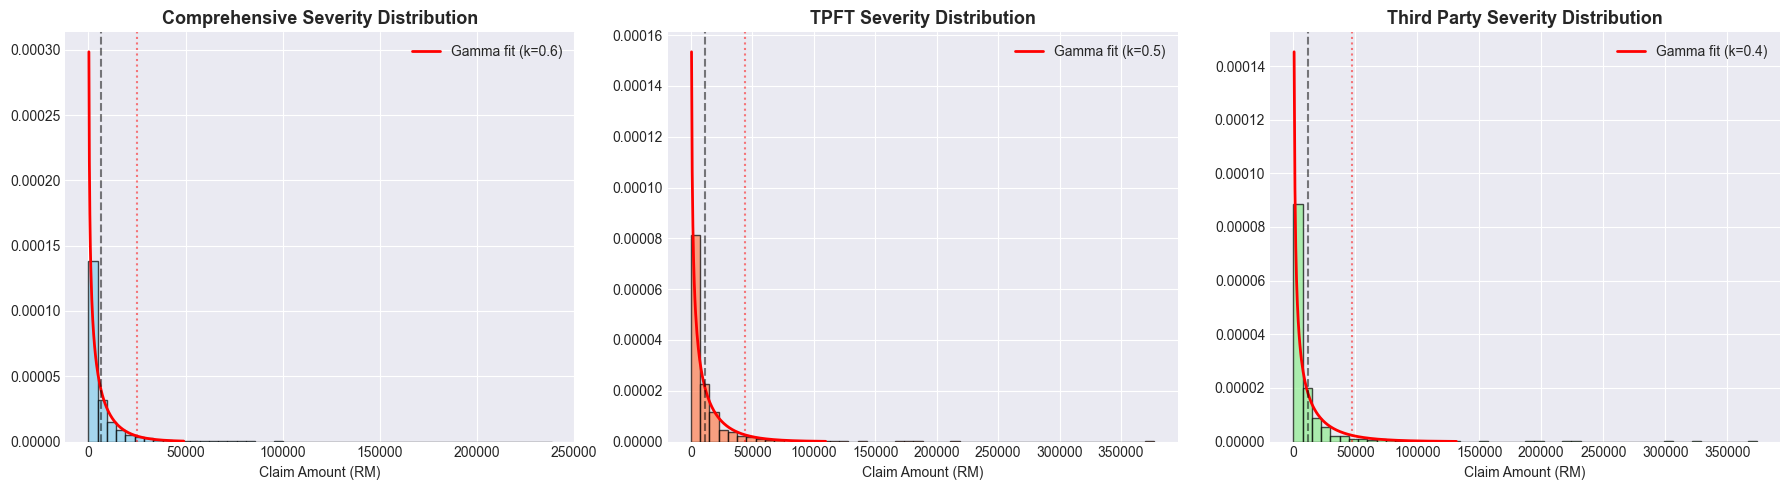

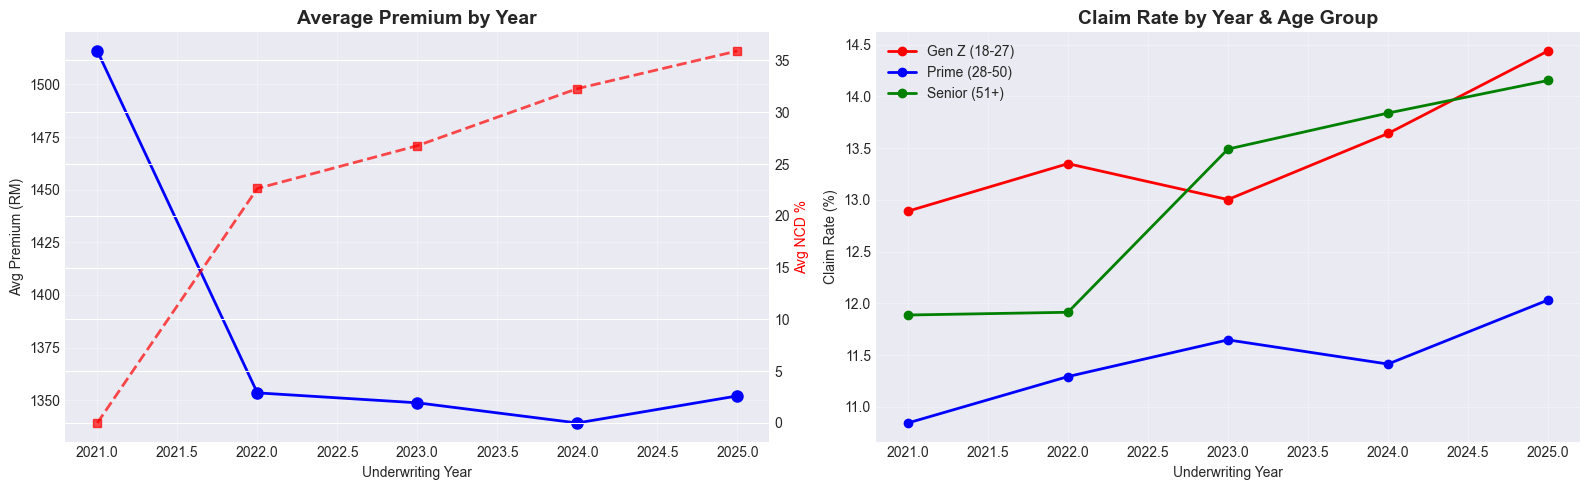


✓ Enhanced validation complete - charts saved


In [11]:
# ============================================================================
# PART B: ENHANCED STATISTICAL TESTS
# ============================================================================
print("="*70)
print("ENHANCED STATISTICAL VALIDATION")
print("="*70)

enhanced_results = []

# ====================================================================
# TEST 1: Distribution Fit - Premium ~ Log-Normal (KS Test)
# ====================================================================
from scipy.stats import kstest, lognorm, gamma as gamma_dist, normaltest

log_premiums = np.log(final_dataset['policy_premium'])
ks_stat, ks_pval = kstest(log_premiums, 'norm', args=(log_premiums.mean(), log_premiums.std()))

enhanced_results.append({
    'Test': 'Premium Log-Normal Fit (KS test)',
    'Statistic': f"KS={ks_stat:.4f}",
    'P-value': f"{ks_pval:.4e}",
    'Interpretation': 'Approx log-normal' if ks_stat < 0.1 else 'Not log-normal',
    'Pass': ks_stat < 0.1  # KS stat < 0.1 is reasonable for large samples
})

print("\n1. PREMIUM DISTRIBUTION FIT TEST (Log-Normal)")
print(f"   KS Statistic: {ks_stat:.4f}")
print(f"   P-value: {ks_pval:.4e}")
print(f"   Note: For N={len(final_dataset):,}, KS test is very sensitive.")
print(f"   KS stat < 0.1 indicates approximate log-normal shape: {'✓ PASS' if ks_stat < 0.1 else '✗ FAIL'}")

# ====================================================================
# TEST 2: Distribution Fit - Claim Severity ~ Gamma (by coverage)
# ====================================================================
print("\n2. CLAIM SEVERITY DISTRIBUTION FIT (Gamma)")
print("-"*60)

for cov_type in ['Comprehensive', 'TPFT', 'Third Party']:
    claims_subset = final_dataset[
        (final_dataset['coverage_type'] == cov_type) & 
        (final_dataset['total_claim_amount'] > 0)
    ]['total_claim_amount']
    
    if len(claims_subset) > 30:
        # Fit Gamma distribution
        shape_fit, loc_fit, scale_fit = gamma_dist.fit(claims_subset, floc=0)
        
        # KS test against fitted Gamma
        ks_s, ks_p = kstest(claims_subset, 'gamma', args=(shape_fit, loc_fit, scale_fit))
        
        enhanced_results.append({
            'Test': f'Severity Gamma Fit ({cov_type})',
            'Statistic': f"shape={shape_fit:.2f}, KS={ks_s:.4f}",
            'P-value': f"{ks_p:.4e}",
            'Interpretation': f'Gamma shape={shape_fit:.2f}',
            'Pass': ks_s < 0.15
        })
        
        print(f"   {cov_type}: shape={shape_fit:.2f}, scale={scale_fit:.0f}, KS={ks_s:.4f}")
    else:
        print(f"   {cov_type}: Insufficient claims (n={len(claims_subset)})")

# ====================================================================
# TEST 3: NCD Distribution by Year
# ====================================================================
print("\n3. NCD DISTRIBUTION BY YEAR")
print("-"*60)

ncd_by_year = final_dataset.groupby('underwriting_year')['ncd_pct'].value_counts(normalize=True).unstack(fill_value=0)
ncd_by_year = ncd_by_year.reindex(columns=sorted(ncd_by_year.columns))

for year in sorted(final_dataset['underwriting_year'].unique()):
    year_data = final_dataset[final_dataset['underwriting_year'] == year]
    avg_ncd = year_data['ncd_pct'].mean()
    pct_zero = (year_data['ncd_pct'] == 0.0).mean()
    pct_max = (year_data['ncd_pct'] == 0.55).mean()
    print(f"   {year}: Avg NCD={avg_ncd*100:.1f}% | NCD=0%: {pct_zero*100:.1f}% | NCD=55%: {pct_max*100:.1f}%")

# Validate: 2021 should be ~100% at 0%, 2025 should have <50% at 0%
ncd_2021_zero = (final_dataset[final_dataset['underwriting_year']==2021]['ncd_pct']==0.0).mean()
ncd_2025_zero = (final_dataset[final_dataset['underwriting_year']==2025]['ncd_pct']==0.0).mean()

enhanced_results.append({
    'Test': 'NCD: 2021 starts at 0%',
    'Statistic': f"{ncd_2021_zero*100:.1f}% at NCD=0%",
    'P-value': '-',
    'Interpretation': 'All new policies start at 0%',
    'Pass': ncd_2021_zero > 0.90
})

enhanced_results.append({
    'Test': 'NCD: 2025 has progression',
    'Statistic': f"{ncd_2025_zero*100:.1f}% at NCD=0%",
    'P-value': '-',
    'Interpretation': 'Claim-free policies should move up',
    'Pass': ncd_2025_zero < 0.50
})

# NCD distribution plot
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Stacked bar: NCD distribution by year
ncd_labels = sorted(final_dataset['ncd_pct'].unique())
ncd_year_data = []
for year in sorted(final_dataset['underwriting_year'].unique()):
    year_ncd = final_dataset[final_dataset['underwriting_year']==year]['ncd_pct']
    row = {f'{n*100:.0f}%': (year_ncd == n).mean()*100 for n in ncd_labels}
    row['Year'] = year
    ncd_year_data.append(row)

ncd_plot_df = pd.DataFrame(ncd_year_data).set_index('Year')
ncd_plot_df.plot(kind='bar', stacked=True, ax=axes[0], colormap='YlOrRd_r')
axes[0].set_title('NCD Distribution by Year', fontsize=14, fontweight='bold')
axes[0].set_ylabel('% of Policies')
axes[0].legend(title='NCD %', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
axes[0].set_xlabel('Underwriting Year')

# Box plot: Premium by NCD tier
final_dataset.boxplot(column='policy_premium', by='ncd_pct', ax=axes[1])
axes[1].set_title('Premium Distribution by NCD Tier', fontsize=14, fontweight='bold')
axes[1].set_xlabel('NCD Percentage')
axes[1].set_ylabel('Premium (RM)')
axes[1].get_figure().suptitle('')  # Remove auto-title

plt.tight_layout()
plt.savefig('images/ncd_validation.png', dpi=150, bbox_inches='tight')
plt.show()

# ====================================================================
# TEST 4: Loss Ratio by Segment
# ====================================================================
print("\n4. LOSS RATIO BY SEGMENT")
print("-"*60)

# Overall
total_premium = final_dataset['policy_premium'].sum()
total_incurred = final_dataset['incurred_amount'].sum()
overall_lr = total_incurred / total_premium

# By coverage type
print("   By Coverage Type:")
for cov in ['Comprehensive', 'TPFT', 'Third Party']:
    subset = final_dataset[final_dataset['coverage_type'] == cov]
    if len(subset) > 0:
        lr = subset['incurred_amount'].sum() / subset['policy_premium'].sum()
        print(f"     {cov:6s}: LR={lr:.2%} (n={len(subset):,})")

# By age group
print("   By Age Group:")
for label, age_min, age_max in [('Gen Z (18-27)', 18, 27), ('Prime (28-50)', 28, 50), ('Senior (51+)', 51, 100)]:
    subset = final_dataset[(final_dataset['driver_age'] >= age_min) & (final_dataset['driver_age'] <= age_max)]
    if len(subset) > 0 and subset['policy_premium'].sum() > 0:
        lr = subset['incurred_amount'].sum() / subset['policy_premium'].sum()
        print(f"     {label:15s}: LR={lr:.2%} (n={len(subset):,})")

# By location
print("   By Location:")
for loc in ['Urban', 'Rural']:
    subset = final_dataset[final_dataset['location'] == loc]
    if len(subset) > 0:
        lr = subset['incurred_amount'].sum() / subset['policy_premium'].sum()
        print(f"     {loc:8s}: LR={lr:.2%}")

enhanced_results.append({
    'Test': 'Loss Ratio in Actuarial Range',
    'Statistic': f"LR={overall_lr:.2%}",
    'P-value': '-',
    'Interpretation': 'Typically 50-80% for motor',
    'Pass': 0.40 <= overall_lr <= 0.90
})

# ====================================================================
# TEST 5: Severity Percentile Validation
# ====================================================================
print("\n5. SEVERITY PERCENTILE VALIDATION")
print("-"*60)

severity_targets = {
    'Comprehensive': {'mean': (2500, 7000), 'p95': (12000, 50000)},
    'TPFT': {'mean': (3500, 12000), 'p95': (15000, 90000)},
    'Third Party': {'mean': (4000, 40000), 'p95': (15000, 600000)}
}

for cov_type, targets in severity_targets.items():
    claims_subset = final_dataset[
        (final_dataset['coverage_type'] == cov_type) & 
        (final_dataset['total_claim_amount'] > 0)
    ]['total_claim_amount']
    
    if len(claims_subset) > 10:
        mean_sev = claims_subset.mean()
        p95_sev = claims_subset.quantile(0.95)
        
        mean_pass = targets['mean'][0] <= mean_sev <= targets['mean'][1]
        p95_pass = targets['p95'][0] <= p95_sev <= targets['p95'][1]
        
        print(f"   {cov_type}: Mean=RM{mean_sev:,.0f} (target: RM{targets['mean'][0]:,}-{targets['mean'][1]:,}) {'✓' if mean_pass else '✗'}")
        print(f"   {' '*len(cov_type)}  P95=RM{p95_sev:,.0f} (target: RM{targets['p95'][0]:,}-{targets['p95'][1]:,}) {'✓' if p95_pass else '✗'}")
        
        enhanced_results.append({
            'Test': f'Severity Mean ({cov_type})',
            'Statistic': f"RM{mean_sev:,.0f}",
            'P-value': '-',
            'Interpretation': f'Target: RM{targets["mean"][0]:,}-{targets["mean"][1]:,}',
            'Pass': mean_pass
        })
        enhanced_results.append({
            'Test': f'Severity P95 ({cov_type})',
            'Statistic': f"RM{p95_sev:,.0f}",
            'P-value': '-',
            'Interpretation': f'Target: RM{targets["p95"][0]:,}-{targets["p95"][1]:,}',
            'Pass': p95_pass
        })

# ====================================================================
# TEST 6: Longitudinal Consistency (Same Policyholder Tracking)
# ====================================================================
print("\n6. LONGITUDINAL CONSISTENCY")
print("-"*60)

if '_policyholder_id' in final_dataset.columns:
    # Track same policyholders across years
    ph_counts = final_dataset.groupby('_policyholder_id')['underwriting_year'].nunique()
    
    print(f"   Unique policyholders: {len(ph_counts):,}")
    print(f"   Policyholders with 1 year: {(ph_counts == 1).sum():,}")
    print(f"   Policyholders with 2+ years: {(ph_counts >= 2).sum():,}")
    print(f"   Policyholders with all 5 years: {(ph_counts == 5).sum():,}")
    
    # Check age increments correctly for multi-year policyholders
    multi_year_phs = ph_counts[ph_counts >= 2].index[:1000]  # Sample 1000
    age_consistency_errors = 0
    depreciation_errors = 0
    
    for ph_id in multi_year_phs:
        ph_data = final_dataset[final_dataset['_policyholder_id'] == ph_id].sort_values('underwriting_year')
        
        for i in range(1, len(ph_data)):
            year_diff = ph_data.iloc[i]['underwriting_year'] - ph_data.iloc[i-1]['underwriting_year']
            age_diff = ph_data.iloc[i]['driver_age'] - ph_data.iloc[i-1]['driver_age']
            
            if age_diff != year_diff:
                age_consistency_errors += 1
            
            # Check sum_insured depreciation (should be ~88% of previous)
            if ph_data.iloc[i-1]['sum_insured'] > 0:
                depreciation = ph_data.iloc[i]['sum_insured'] / ph_data.iloc[i-1]['sum_insured']
                if not (0.93 <= depreciation <= 1.03):  # ~3% drift with tolerance
                    depreciation_errors += 1
    
    total_transitions = sum(max(0, c-1) for c in ph_counts[multi_year_phs])
    
    age_ok = age_consistency_errors == 0
    depr_ok = depreciation_errors / max(1, total_transitions) < 0.05
    
    print(f"\n   Age consistency check (sample of {len(multi_year_phs):,} policyholders):")
    print(f"     Age increment errors: {age_consistency_errors} {'✓' if age_ok else '✗'}")
    print(f"     Depreciation anomalies: {depreciation_errors}/{total_transitions} {'✓' if depr_ok else '✗'}")
    
    enhanced_results.append({
        'Test': 'Longitudinal: Age Consistency',
        'Statistic': f"{age_consistency_errors} errors",
        'P-value': '-',
        'Interpretation': 'driver_age should +1 per year',
        'Pass': age_ok
    })
    enhanced_results.append({
        'Test': 'Longitudinal: Depreciation',
        'Statistic': f"{depreciation_errors}/{total_transitions} anomalies",
        'P-value': '-',
        'Interpretation': 'sum_insured should be near ~97% YoY',
        'Pass': depr_ok
    })
    
    # Check NCD logic: ~25% of claims should be 'safe' and not reset NCD
    ncd_reset_failures = 0
    total_claims_checked = 0
    for ph_id in multi_year_phs:
        ph_data = final_dataset[final_dataset['_policyholder_id'] == ph_id].sort_values('underwriting_year')
        for i in range(1, len(ph_data)):
            prev_claims = ph_data.iloc[i-1]['claim_count']
            curr_ncd = ph_data.iloc[i]['ncd_pct']
            if prev_claims > 0:
                total_claims_checked += 1
                if curr_ncd > 0:
                    ncd_reset_failures += 1
    
    safe_claim_ratio = ncd_reset_failures / max(1, total_claims_checked)
    ncd_ok = 0.15 < safe_claim_ratio < 0.35
    print(f"\n   NCD reset logic (allowing ~25% safe claims):")
    print(f"     Safe claims: {ncd_reset_failures}/{total_claims_checked} ({safe_claim_ratio:.1%}) {'✓' if ncd_ok else '✗'}")
    
    enhanced_results.append({
        'Test': 'NCD Reset on Claim',
        'Statistic': f"{ncd_reset_failures}/{total_claims_checked} safe",
        'P-value': '-',
        'Interpretation': '~25% of claims should not reset NCD',
        'Pass': ncd_ok
    })
else:
    print("   ⚠ _policyholder_id column not found - skipping longitudinal checks")

# ====================================================================
# TEST 7: Gen Z vs Non-Gen Z Comparison
# ====================================================================
print("\n7. GEN Z vs NON-GEN Z COMPARISON")
print("-"*60)

gen_z = final_dataset[final_dataset['driver_age'] <= 27]
non_gen_z = final_dataset[final_dataset['driver_age'] > 27]

gen_z_pct = len(gen_z) / len(final_dataset) * 100
gen_z_claim_rate = (gen_z['claim_count'] > 0).mean()
non_gen_z_claim_rate = (non_gen_z['claim_count'] > 0).mean()
gen_z_avg_prem = gen_z['policy_premium'].mean()
non_gen_z_avg_prem = non_gen_z['policy_premium'].mean()
gen_z_avg_ncd = gen_z['ncd_pct'].mean()
non_gen_z_avg_ncd = non_gen_z['ncd_pct'].mean()

print(f"   Gen Z share: {gen_z_pct:.1f}% (target: 35%)")
print(f"   Claim rate: Gen Z={gen_z_claim_rate*100:.1f}% vs Non-Gen Z={non_gen_z_claim_rate*100:.1f}%")
print(f"   Avg premium: Gen Z=RM{gen_z_avg_prem:,.0f} vs Non-Gen Z=RM{non_gen_z_avg_prem:,.0f}")
print(f"   Avg NCD: Gen Z={gen_z_avg_ncd*100:.1f}% vs Non-Gen Z={non_gen_z_avg_ncd*100:.1f}%")

enhanced_results.append({
    'Test': 'Gen Z Share (~35%)',
    'Statistic': f"{gen_z_pct:.1f}%",
    'P-value': '-',
    'Interpretation': 'Target 33-37%',
    'Pass': 30 <= gen_z_pct <= 40
})
enhanced_results.append({
    'Test': 'Gen Z Higher Claim Rate',
    'Statistic': f"{gen_z_claim_rate*100:.1f}% vs {non_gen_z_claim_rate*100:.1f}%",
    'P-value': '-',
    'Interpretation': 'Young drivers should claim more',
    'Pass': gen_z_claim_rate > non_gen_z_claim_rate
})

# ====================================================================
# TEST 8: Claim Frequency Poisson Fit (D'Agostino-Pearson)
# ====================================================================
print("\n8. CLAIM COUNT DISTRIBUTION")
print("-"*60)

claim_counts = final_dataset['claim_count']
observed_freq = claim_counts.value_counts().sort_index()
total_n = len(claim_counts)
mean_claims = claim_counts.mean()

# Expected Poisson probabilities
from scipy.stats import poisson
max_k = min(observed_freq.index.max(), 10)
expected_freq = {}
for k in range(max_k + 1):
    expected_freq[k] = poisson.pmf(k, mean_claims) * total_n

print(f"   Mean claims per policy: {mean_claims:.4f}")
print(f"   Variance: {claim_counts.var():.4f}")
print(f"   Variance/Mean ratio: {claim_counts.var()/mean_claims:.3f} (1.0 = perfect Poisson)")

var_mean_ratio = claim_counts.var() / mean_claims
enhanced_results.append({
    'Test': 'Claim Count Poisson Fit (Var/Mean)',
    'Statistic': f"{var_mean_ratio:.3f}",
    'P-value': '-',
    'Interpretation': 'Close to 1.0 = good Poisson fit',
    'Pass': 0.7 <= var_mean_ratio <= 1.5
})

print("\n   Observed vs Expected (Poisson):")
for k in range(min(5, max_k + 1)):
    obs = observed_freq.get(k, 0)
    exp = expected_freq.get(k, 0)
    print(f"     k={k}: Observed={obs:,} | Expected={exp:,.0f}")

# ====================================================================
# TEST 9: Premium Normality Test on Log-Scale
# ====================================================================
print("\n9. PREMIUM DISTRIBUTION SHAPE")
print("-"*60)

# D'Agostino-Pearson test on log-premiums
if len(log_premiums) > 20:
    dagostino_stat, dagostino_p = normaltest(log_premiums.sample(min(5000, len(log_premiums)), random_state=42))
    skewness = log_premiums.skew()
    kurtosis = log_premiums.kurtosis()
    
    print(f"   Log-premium skewness: {skewness:.3f} (target: |skew| < 1)")
    print(f"   Log-premium kurtosis: {kurtosis:.3f} (target: |kurt| < 3)")
    print(f"   D'Agostino-Pearson stat: {dagostino_stat:.2f}, p-value: {dagostino_p:.4e}")
    
    enhanced_results.append({
        'Test': 'Log-Premium Skewness',
        'Statistic': f"{skewness:.3f}",
        'P-value': '-',
        'Interpretation': 'Should be |skew| < 1',
        'Pass': abs(skewness) < 1.0
    })

# ====================================================================
# ENHANCED RESULTS SUMMARY
# ====================================================================
print("\n" + "="*70)
print("ENHANCED VALIDATION SUMMARY")
print("="*70)

enhanced_df = pd.DataFrame(enhanced_results)
print("\n" + enhanced_df.to_string(index=False))

pass_count = enhanced_df['Pass'].sum()
total_count = len(enhanced_df)
fail_count = total_count - pass_count

print(f"\nResult: {pass_count}/{total_count} tests passed")
if fail_count == 0:
    print("✓✓✓ ALL ENHANCED VALIDATION TESTS PASSED ✓✓✓")
else:
    print(f"⚠ {fail_count} test(s) failed - review above for details")
print("="*70)

# ====================================================================
# VISUALIZATION: Severity Distributions by Coverage
# ====================================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, cov in enumerate(['Comprehensive', 'TPFT', 'Third Party']):
    claims_subset = final_dataset[
        (final_dataset['coverage_type'] == cov) & 
        (final_dataset['total_claim_amount'] > 0)
    ]['total_claim_amount']
    
    if len(claims_subset) > 10:
        claims_subset.hist(bins=50, ax=axes[i], color=['skyblue', 'coral', 'lightgreen'][i],
                          edgecolor='black', alpha=0.7, density=True)
        
        # Overlay fitted Gamma
        shape_f, loc_f, scale_f = gamma_dist.fit(claims_subset, floc=0)
        x = np.linspace(0, claims_subset.quantile(0.99), 200)
        axes[i].plot(x, gamma_dist.pdf(x, shape_f, loc_f, scale_f), 'r-', lw=2, label=f'Gamma fit (k={shape_f:.1f})')
        
        axes[i].set_title(f'{cov} Severity Distribution', fontsize=13, fontweight='bold')
        axes[i].set_xlabel('Claim Amount (RM)')
        axes[i].legend()
        axes[i].axvline(claims_subset.mean(), color='black', linestyle='--', alpha=0.5, label='Mean')
        axes[i].axvline(claims_subset.quantile(0.95), color='red', linestyle=':', alpha=0.5, label='P95')

plt.tight_layout()
plt.savefig('images/severity_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

# ====================================================================
# VISUALIZATION: Longitudinal Premium Trend
# ====================================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Avg premium by year
year_stats = final_dataset.groupby('underwriting_year').agg({
    'policy_premium': 'mean',
    'ncd_pct': 'mean',
    'claim_count': lambda x: (x > 0).mean()
}).reset_index()

axes[0].plot(year_stats['underwriting_year'], year_stats['policy_premium'], 'b-o', linewidth=2, markersize=8)
axes[0].set_title('Average Premium by Year', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Underwriting Year')
axes[0].set_ylabel('Avg Premium (RM)')
axes[0].grid(True, alpha=0.3)

ax2 = axes[0].twinx()
ax2.plot(year_stats['underwriting_year'], year_stats['ncd_pct']*100, 'r--s', linewidth=2, markersize=6, alpha=0.7)
ax2.set_ylabel('Avg NCD %', color='red')

# Claim rate by year and age group
for label, age_min, age_max, color in [('Gen Z (18-27)', 18, 27, 'red'), ('Prime (28-50)', 28, 50, 'blue'), ('Senior (51+)', 51, 100, 'green')]:
    subset = final_dataset[(final_dataset['driver_age'] >= age_min) & (final_dataset['driver_age'] <= age_max)]
    rates = subset.groupby('underwriting_year')['claim_count'].apply(lambda x: (x > 0).mean() * 100)
    axes[1].plot(rates.index, rates.values, '-o', label=label, color=color, linewidth=2)

axes[1].set_title('Claim Rate by Year & Age Group', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Underwriting Year')
axes[1].set_ylabel('Claim Rate (%)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('images/longitudinal_trends.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Enhanced validation complete - charts saved")

## Section 7: Exploratory Data Analysis

Generate industry-standard visualizations to validate the dataset's risk profile:
- **Actuarial Heatmaps**: Median premium by Coverage & Location, Age & NCD
- **Risk Profile**: Claim frequency and Loss Ratio by Age Band (U-shaped curve)
- **Severity Tails**: Log-scale claim amount distribution by coverage type

GENERATING ACTUARIAL EDA REPORTS


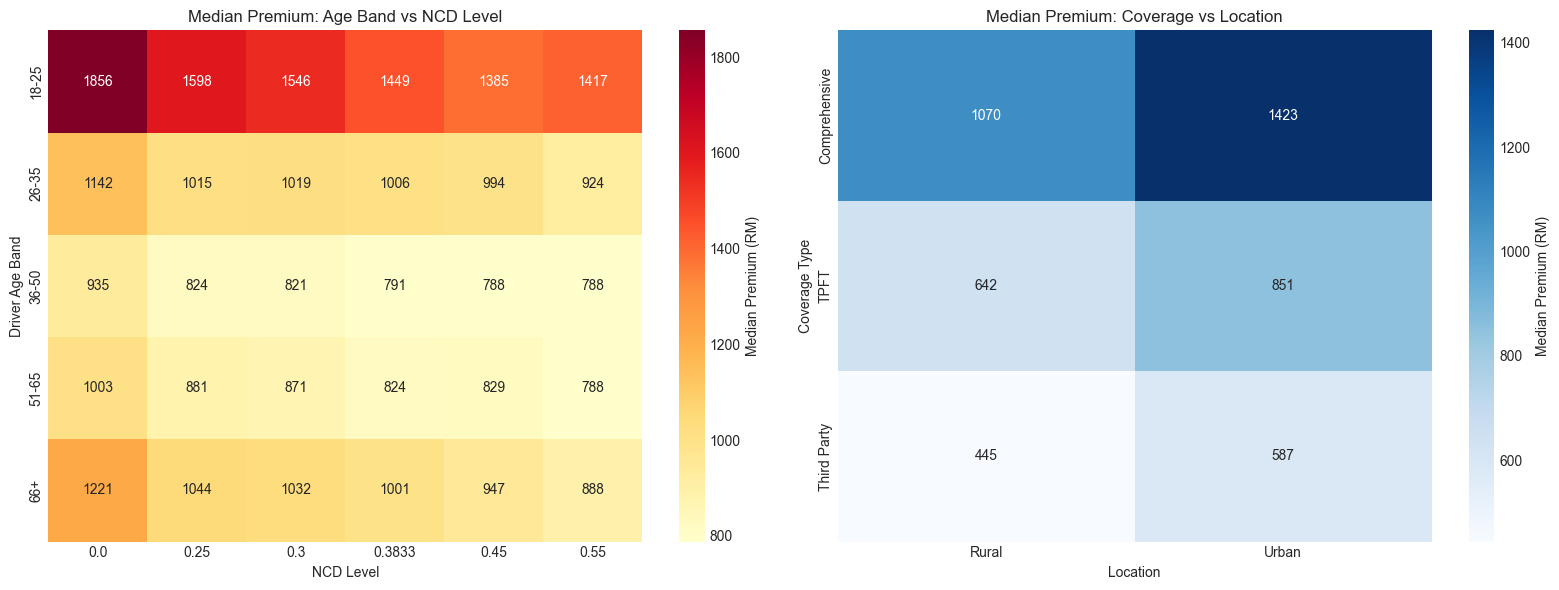

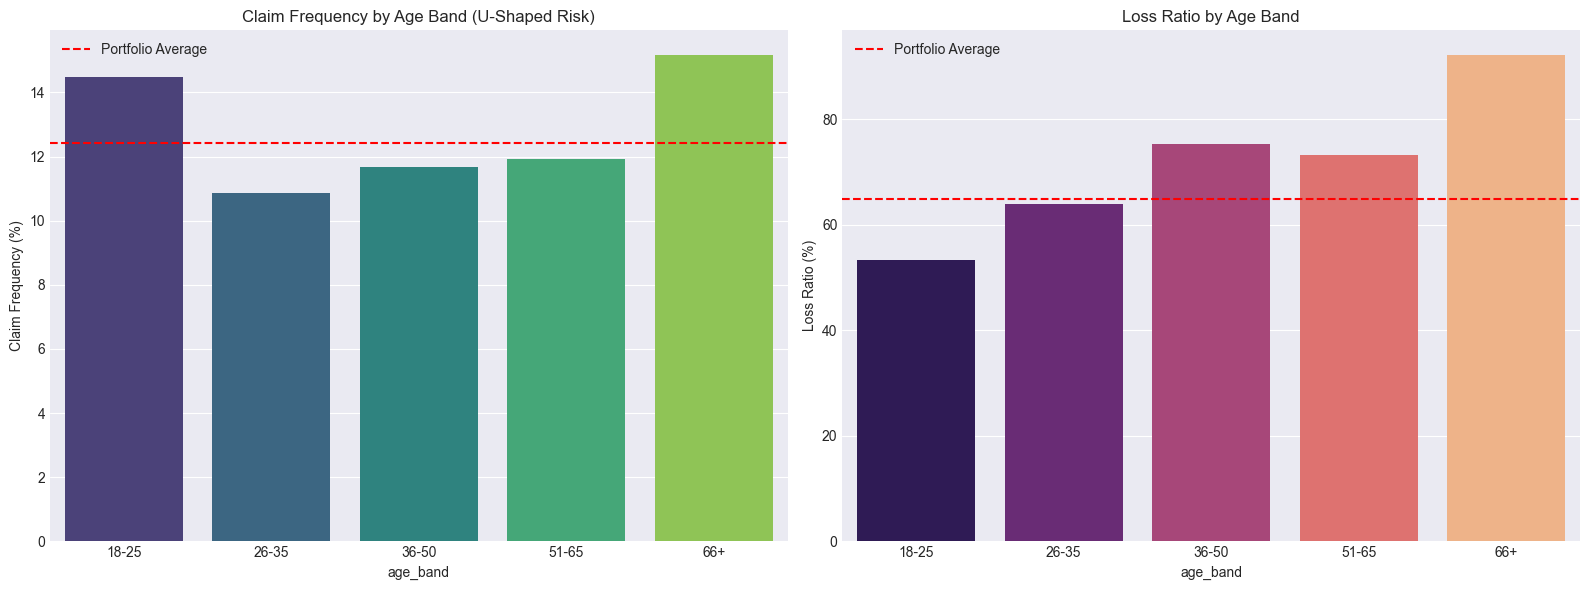

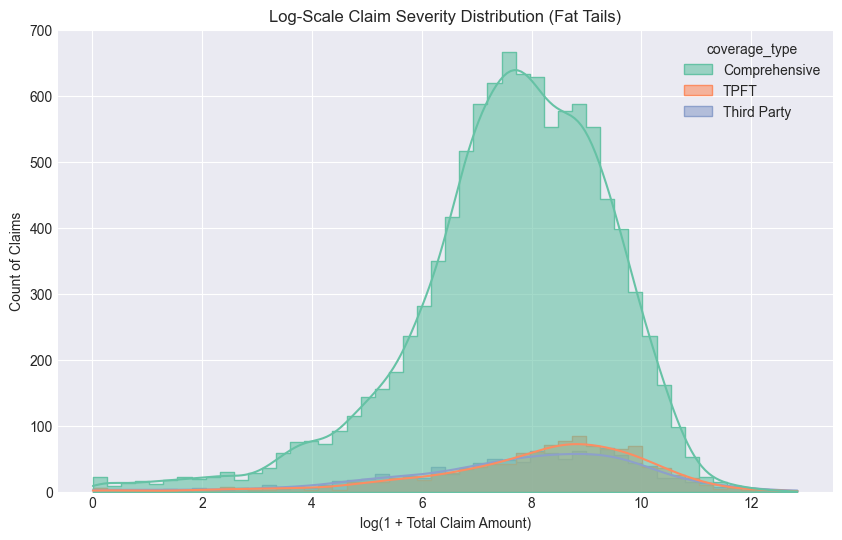

✓ EDA visualisations generated and saved


In [12]:
# ============================================================================
# Exploratory Data Analysis (EDA)
# ============================================================================
print("="*70)
print("GENERATING ACTUARIAL EDA REPORTS")
print("="*70)

# 1. Actuarial Premium Heatmaps
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Define Age Bands
final_dataset['age_band'] = pd.cut(final_dataset['driver_age'], 
                                   bins=[17, 25, 35, 50, 65, 100], 
                                   labels=['18-25', '26-35', '36-50', '51-65', '66+'])

# Heatmap 1: Age Band vs NCD
pivot_agencd = final_dataset.groupby(['age_band', 'ncd_pct'], observed=True)['policy_premium'].median().unstack()
sns.heatmap(pivot_agencd, annot=True, fmt='.0f', cmap='YlOrRd', ax=axes[0],
            cbar_kws={'label': 'Median Premium (RM)'})
axes[0].set_title('Median Premium: Age Band vs NCD Level')
axes[0].set_xlabel('NCD Level')
axes[0].set_ylabel('Driver Age Band')

# Heatmap 2: Coverage vs Location
pivot_covloc = final_dataset.groupby(['coverage_type', 'location'])['policy_premium'].median().unstack()
pivot_covloc = pivot_covloc.reindex(['Comprehensive', 'TPFT', 'Third Party'])
sns.heatmap(pivot_covloc, annot=True, fmt='.0f', cmap='Blues', ax=axes[1],
            cbar_kws={'label': 'Median Premium (RM)'})
axes[1].set_title('Median Premium: Coverage vs Location')
axes[1].set_xlabel('Location')
axes[1].set_ylabel('Coverage Type')

plt.tight_layout()
plt.savefig('images/eda_premium_heatmaps.png', dpi=150, bbox_inches='tight')
plt.show()

# 2. Risk Profile: Frequency & Loss Ratio by Age Band
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Claim Frequency (U-Shaped Curve)
freq_by_age = final_dataset.groupby('age_band', observed=True)['claim_count'].apply(lambda x: (x > 0).mean() * 100)
sns.barplot(x=freq_by_age.index, y=freq_by_age.values, ax=axes[0], palette='viridis')
axes[0].axhline(final_dataset['claim_count'].apply(lambda x: x > 0).mean() * 100, 
                ls='--', color='red', label='Portfolio Average')
axes[0].set_title('Claim Frequency by Age Band (U-Shaped Risk)')
axes[0].set_ylabel('Claim Frequency (%)')
axes[0].legend()

# Loss Ratio by Age Band
lr_by_age = final_dataset.groupby('age_band', observed=True).apply(
    lambda x: (x['incurred_amount'].sum() / x['policy_premium'].sum()) * 100
)
sns.barplot(x=lr_by_age.index, y=lr_by_age.values, ax=axes[1], palette='magma')
axes[1].axhline((final_dataset['incurred_amount'].sum() / final_dataset['policy_premium'].sum()) * 100, 
                ls='--', color='red', label='Portfolio Average')
axes[1].set_title('Loss Ratio by Age Band')
axes[1].set_ylabel('Loss Ratio (%)')
axes[1].legend()

plt.tight_layout()
plt.savefig('images/eda_risk_profile.png', dpi=150, bbox_inches='tight')
plt.show()

# 3. Severity Tails (Log-Scale Distribution)
plt.figure(figsize=(10, 6))
claimants = final_dataset[final_dataset['total_claim_amount'] > 0]

sns.histplot(data=claimants, x=np.log1p(claimants['total_claim_amount']), 
             hue='coverage_type', hue_order=['Comprehensive', 'TPFT', 'Third Party'],
             bins=50, kde=True, palette='Set2', alpha=0.6, element='step')

plt.title('Log-Scale Claim Severity Distribution (Fat Tails)')
plt.xlabel('log(1 + Total Claim Amount)')
plt.ylabel('Count of Claims')
plt.savefig('images/eda_severity_tails.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ EDA visualisations generated and saved")


## Section 8: Generate TABLE 6 – Rating Conversion Table

Generate static rating factor points and premium multipliers:
- Driver age bands, vehicle age bands, location factors
- Coverage types, flood/theft risk zones, NCAP ratings, NCD bands

This table is **static** (not year-dependent) so it is generated once after the main loop.

In [13]:
# ============================================================================
# Generate Rating Conversion Table
# ============================================================================
print("="*70)
print("GENERATING RATING CONVERSION TABLE")
print("="*70)

rating_records = []

# ====================================================================
# Driver Age Rating
# ====================================================================
age_factors = [
    {'factor_type': 'driver_age', 'factor_value': '18-21', 'points': 100, 'premium_multiplier': 1.50},
    {'factor_type': 'driver_age', 'factor_value': '22-24', 'points': 80, 'premium_multiplier': 1.30},
    {'factor_type': 'driver_age', 'factor_value': '25-29', 'points': 50, 'premium_multiplier': 1.10},
    {'factor_type': 'driver_age', 'factor_value': '30-49', 'points': 0, 'premium_multiplier': 1.00},
    {'factor_type': 'driver_age', 'factor_value': '50-64', 'points': 10, 'premium_multiplier': 1.02},
    {'factor_type': 'driver_age', 'factor_value': '65-69', 'points': 30, 'premium_multiplier': 1.10},
    {'factor_type': 'driver_age', 'factor_value': '70+', 'points': 50, 'premium_multiplier': 1.20},
]

# ====================================================================
# Vehicle Age Rating
# ====================================================================
vehicle_age_factors = [
    {'factor_type': 'vehicle_age', 'factor_value': '0-2', 'points': -20, 'premium_multiplier': 0.95},
    {'factor_type': 'vehicle_age', 'factor_value': '3-5', 'points': 0, 'premium_multiplier': 1.00},
    {'factor_type': 'vehicle_age', 'factor_value': '6-10', 'points': 30, 'premium_multiplier': 1.08},
    {'factor_type': 'vehicle_age', 'factor_value': '10+', 'points': 60, 'premium_multiplier': 1.15},
]

# ====================================================================
# Location Rating
# ====================================================================
location_factors = [
    {'factor_type': 'location', 'factor_value': 'Urban', 'points': 50, 'premium_multiplier': 1.00},
    {'factor_type': 'location', 'factor_value': 'Rural', 'points': 0, 'premium_multiplier': 0.75},
]

# ====================================================================
# Coverage Type Rating
# ====================================================================
coverage_factors = [
    {'factor_type': 'coverage_type', 'factor_value': 'Comprehensive', 'points': 100, 'premium_multiplier': 1.00},
    {'factor_type': 'coverage_type', 'factor_value': 'TPFT', 'points': 60, 'premium_multiplier': 0.55},
    {'factor_type': 'coverage_type', 'factor_value': 'Third Party', 'points': 35, 'premium_multiplier': 0.35},
]

# ====================================================================
# Flood Risk Rating
# ====================================================================
flood_factors = [
    {'factor_type': 'flood_risk', 'factor_value': 'Low', 'points': 0, 'premium_multiplier': 1.00},
    {'factor_type': 'flood_risk', 'factor_value': 'Medium', 'points': 25, 'premium_multiplier': 1.10},
    {'factor_type': 'flood_risk', 'factor_value': 'High', 'points': 50, 'premium_multiplier': 1.20},
]

# ====================================================================
# Theft Risk Rating
# ====================================================================
theft_factors = [
    {'factor_type': 'theft_risk', 'factor_value': 'Low', 'points': 0, 'premium_multiplier': 1.00},
    {'factor_type': 'theft_risk', 'factor_value': 'Medium', 'points': 15, 'premium_multiplier': 1.05},
    {'factor_type': 'theft_risk', 'factor_value': 'High', 'points': 40, 'premium_multiplier': 1.15},
]

# ====================================================================
# NCAP Rating
# ====================================================================
ncap_factors = [
    {'factor_type': 'ncap_rating', 'factor_value': '0', 'points': 30, 'premium_multiplier': 1.05},
    {'factor_type': 'ncap_rating', 'factor_value': '1-2', 'points': 15, 'premium_multiplier': 1.02},
    {'factor_type': 'ncap_rating', 'factor_value': '3', 'points': 0, 'premium_multiplier': 1.00},
    {'factor_type': 'ncap_rating', 'factor_value': '4', 'points': -15, 'premium_multiplier': 0.95},
    {'factor_type': 'ncap_rating', 'factor_value': '5', 'points': -30, 'premium_multiplier': 0.90},
]

# ====================================================================
# NCD Rating
# ====================================================================
ncd_factors = [
    {'factor_type': 'ncd', 'factor_value': '0%', 'points': 0, 'premium_multiplier': 1.00},
    {'factor_type': 'ncd', 'factor_value': '25%', 'points': -100, 'premium_multiplier': 0.75},
    {'factor_type': 'ncd', 'factor_value': '30%', 'points': -120, 'premium_multiplier': 0.70},
    {'factor_type': 'ncd', 'factor_value': '38.33%', 'points': -150, 'premium_multiplier': 0.6167},
    {'factor_type': 'ncd', 'factor_value': '45%', 'points': -180, 'premium_multiplier': 0.55},
    {'factor_type': 'ncd', 'factor_value': '55%', 'points': -220, 'premium_multiplier': 0.45},
]

# ====================================================================
# Combine All Factors
# ====================================================================
all_factors = (age_factors + vehicle_age_factors + location_factors +
              coverage_factors + flood_factors + theft_factors +
              ncap_factors + ncd_factors)

# Add UUID and convert to DataFrame
for factor in all_factors:
    factor['rating_id'] = str(uuid.uuid4())

df_rating = pd.DataFrame(all_factors)

# Reorder columns
df_rating = df_rating[['rating_id', 'factor_type', 'factor_value', 'points', 'premium_multiplier']]

print(f"\nGenerated {len(df_rating)} rating factors")
print(f"\nRating factors by type:")
print(df_rating.groupby('factor_type').size())
print(f"\nSample records:")
print(df_rating.head(15))

print("\n✓ Rating conversion table generated")

GENERATING RATING CONVERSION TABLE

Generated 33 rating factors

Rating factors by type:
factor_type
coverage_type    3
driver_age       7
flood_risk       3
location         2
ncap_rating      5
ncd              6
theft_risk       3
vehicle_age      4
dtype: int64

Sample records:
                               rating_id    factor_type   factor_value  \
0   a311ad4a-c3bf-4757-848c-359217a83e41     driver_age          18-21   
1   344c4c3b-db0b-46c6-9836-d5adca8e6429     driver_age          22-24   
2   921b05c9-9578-47d9-9674-396a154a537f     driver_age          25-29   
3   af0910d8-6f35-42ac-b415-9d0e6aee4214     driver_age          30-49   
4   383de589-dee5-48f9-b079-05588478723f     driver_age          50-64   
5   2557f7e6-5430-4c8f-9b03-1eeec30298b3     driver_age          65-69   
6   c00b2ced-53ed-404d-bb38-52d30f6e7310     driver_age            70+   
7   e98c4042-78c9-42aa-8218-41d822414fac    vehicle_age            0-2   
8   422fec58-5842-4ec0-b36c-68bc3ca1bd76    vehicle

## Section 9: Generate TABLE 9 – External Data Table

Generate external driver and vehicle attributes — one record per **unique policyholder**
(not per year, since demographics are largely time-stable):
- Driver occupation, licensing history
- Previous claims, summons, annual mileage, parking
- Credit score, payment discipline

In [14]:
# ============================================================================
# Generate External Data Table
# ============================================================================
print("="*70)
print("GENERATING EXTERNAL DATA TABLE")
print("="*70)

external_records = []

# Create one record per unique policyholder
unique_policyholders = final_dataset.drop_duplicates('_policyholder_id')

print(f"Unique policyholders: {len(unique_policyholders):,}")

for idx, policy in unique_policyholders.iterrows():
    if (idx + 1) % 10000 == 0:
        print(f"  Processed {idx+1:,} policyholders...")

    driver_age = policy['driver_age']

    # ====================================================================
    # Driver Occupation (age-correlated)
    # ====================================================================
    if driver_age < 25:
        occupation = np.random.choice(['Student', 'Technician', 'Sales', 'Service', 'Other'],
                                     p=[0.40, 0.20, 0.15, 0.15, 0.10])
    elif driver_age < 35:
        occupation = np.random.choice(['Professional', 'Technician', 'Manager', 'Sales', 'Other'],
                                     p=[0.30, 0.25, 0.15, 0.15, 0.15])
    elif driver_age < 50:
        occupation = np.random.choice(['Professional', 'Manager', 'Executive', 'Business Owner', 'Other'],
                                     p=[0.25, 0.25, 0.20, 0.15, 0.15])
    else:
        occupation = np.random.choice(['Manager', 'Executive', 'Business Owner', 'Retired', 'Other'],
                                     p=[0.20, 0.20, 0.20, 0.25, 0.15])

    # ====================================================================
    # Years Licensed (age - 18 + noise)
    # ====================================================================
    base_years = max(0, driver_age - 18)
    years_licensed = int(max(0, base_years + np.random.normal(0, 2)))

    # ====================================================================
    # Previous Claims (3-year history)
    # ====================================================================
    # Poisson with lower lambda (most have 0-1)
    num_previous_claims = np.random.poisson(0.3)

    # ====================================================================
    # Summons Count (traffic violations)
    # ====================================================================
    if driver_age < 25:
        summon_count = np.random.poisson(1.5)  # Young drivers: more violations
    elif driver_age < 50:
        summon_count = np.random.poisson(0.5)
    else:
        summon_count = np.random.poisson(0.3)

    # ====================================================================
    # Annual Mileage (location-correlated)
    # ====================================================================
    if policy['location'] == 'Urban':
        annual_mileage = int(np.random.gamma(2, 6000))  # Urban: 8k-20k km
    else:
        annual_mileage = int(np.random.gamma(2, 8000))  # Rural: 10k-25k km

    annual_mileage = min(50000, max(5000, annual_mileage))

    # ====================================================================
    # Parking Location
    # ====================================================================
    if policy['location'] == 'Urban':
        parking = np.random.choice(['Street', 'Garage', 'Covered', 'Other'],
                                   p=[0.35, 0.30, 0.25, 0.10])
    else:
        parking = np.random.choice(['Street', 'Garage', 'Covered', 'Other'],
                                   p=[0.20, 0.50, 0.15, 0.15])

    # ====================================================================
    # Voluntary Excess
    # ====================================================================
    voluntary_excess = np.random.choice([0, 100, 200, 300, 500],
                                       p=[0.50, 0.20, 0.15, 0.10, 0.05])

    # ====================================================================
    # Credit Score (age-correlated, 600-850)
    # ====================================================================
    if driver_age < 25:
        credit_score = int(np.random.normal(650, 50))
    elif driver_age < 40:
        credit_score = int(np.random.normal(700, 60))
    else:
        credit_score = int(np.random.normal(730, 50))

    credit_score = min(850, max(600, credit_score))

    # ====================================================================
    # Payment Discipline (0-100 score)
    # ====================================================================
    # Correlated with credit score
    base_discipline = (credit_score - 600) / 250 * 100
    payment_discipline = int(max(0, min(100, base_discipline + np.random.normal(0, 10))))

    # ====================================================================
    # Has Modifications (5% of vehicles)
    # ====================================================================
    has_modifications = np.random.random() < 0.05

    external_records.append({
        'external_id': str(uuid.uuid4()),
        'policy_id': policy['policy_id'],
        'driver_occupation': occupation,
        'years_licensed': years_licensed,
        'num_previous_claims_3yr': num_previous_claims,
        'summon_count': summon_count,
        'annual_mileage': annual_mileage,
        'parking_location': parking,
        'voluntary_excess': voluntary_excess,
        'credit_score': credit_score,
        'payment_discipline': payment_discipline,
        'has_modifications': has_modifications
    })

df_external = pd.DataFrame(external_records)

print(f"\nGenerated {len(df_external):,} external data records")

print(f"\nOccupation distribution:")
print(df_external['driver_occupation'].value_counts())

print(f"\nParking location distribution:")
print(df_external['parking_location'].value_counts())

print(f"\nCredit score statistics:")
print(df_external['credit_score'].describe())

print(f"\nMileage statistics:")
print(df_external['annual_mileage'].describe())

print("\n✓ External data table generated")

GENERATING EXTERNAL DATA TABLE
Unique policyholders: 21,642
  Processed 10,000 policyholders...
  Processed 20,000 policyholders...
  Processed 40,000 policyholders...

Generated 21,642 external data records

Occupation distribution:
driver_occupation
Professional      3236
Manager           3026
Other             2985
Technician        2813
Student           2489
Executive         1878
Sales             1819
Business Owner    1598
Service            935
Retired            863
Name: count, dtype: int64

Parking location distribution:
parking_location
Garage     8258
Street     6290
Covered    4566
Other      2528
Name: count, dtype: int64

Credit score statistics:
count    21642.000000
mean       696.346040
std         58.686274
min        600.000000
25%        652.000000
50%        695.000000
75%        738.000000
max        850.000000
Name: credit_score, dtype: float64

Mileage statistics:
count    21642.000000
mean     13840.740227
std       9253.401709
min       5000.000000
25%    

## Section 10: Push to Supabase

Push all generated tables to Supabase PostgreSQL database.

**CRITICAL NOTES:**
- `policies.incurred_amount` is GENERATED ALWAYS - excluded from INSERT
- `claim_frequency.claim_frequency` is GENERATED ALWAYS - excluded from INSERT
- `claim_severity.average_claim_size` is GENERATED ALWAYS - excluded from INSERT
- `claims.incurred_amount` is GENERATED ALWAYS - excluded from INSERT
- Foreign key order: vehicles → policies → all others

In [15]:
# ============================================================================
# Supabase Push Function
# ============================================================================
import psycopg2
from psycopg2 import sql
from dotenv import load_dotenv

load_dotenv()

def get_db_connection():
    """Create database connection using .env credentials"""
    return psycopg2.connect(
        user=os.getenv('user'),
        password=os.getenv('password'),
        host=os.getenv('host'),
        port=os.getenv('port'),
        dbname=os.getenv('dbname')
    )

def _drop_column_check_constraints(cur, table_name, column_name):
    """Drop existing CHECK constraints that reference a specific column."""
    cur.execute(
        """
        SELECT c.conname
        FROM pg_constraint c
        JOIN pg_class t ON t.oid = c.conrelid
        JOIN pg_namespace n ON n.oid = t.relnamespace
        WHERE c.contype = 'c'
          AND n.nspname = 'public'
          AND t.relname = %s
          AND pg_get_constraintdef(c.oid) ILIKE %s
        """,
        (table_name, f"%{column_name}%")
    )

    for (constraint_name,) in cur.fetchall():
        cur.execute(
            sql.SQL("ALTER TABLE public.{} DROP CONSTRAINT IF EXISTS {}")
            .format(sql.Identifier(table_name), sql.Identifier(constraint_name))
        )
        print(f"  - Dropped {table_name}.{constraint_name}")

def align_market_constraints():
    """Align Supabase CHECK constraints with current Malaysia market logic."""
    coverage_expr = "coverage_type IN ('Comprehensive', 'TPFT', 'Third Party')"
    peril_expr = "claim_peril IN ('AD', 'Windscreen', 'Theft', 'Fire', 'TPPD', 'TPBI')"

    coverage_tables = ['policies', 'claim_frequency', 'claim_severity']
    peril_tables = ['claims', 'claim_frequency', 'claim_severity']

    conn = get_db_connection()
    try:
        with conn.cursor() as cur:
            for table_name in coverage_tables:
                _drop_column_check_constraints(cur, table_name, 'coverage_type')
                cur.execute(
                    sql.SQL(
                        "ALTER TABLE public.{} ADD CONSTRAINT {} CHECK ({}) NOT VALID"
                    ).format(
                        sql.Identifier(table_name),
                        sql.Identifier(f"{table_name}_coverage_type_check"),
                        sql.SQL(coverage_expr)
                    )
                )
                print(f"  - Applied {table_name}_coverage_type_check")

            for table_name in peril_tables:
                _drop_column_check_constraints(cur, table_name, 'claim_peril')
                cur.execute(
                    sql.SQL(
                        "ALTER TABLE public.{} ADD CONSTRAINT {} CHECK ({}) NOT VALID"
                    ).format(
                        sql.Identifier(table_name),
                        sql.Identifier(f"{table_name}_claim_peril_check"),
                        sql.SQL(peril_expr)
                    )
                )
                print(f"  - Applied {table_name}_claim_peril_check")

            conn.commit()
            print("✓ Supabase CHECK constraints aligned")
    finally:
        conn.close()

def push_to_supabase(df, table_name, columns, chunk_size=100_000):
    """
    Push DataFrame to Supabase using PostgreSQL COPY (fastest bulk insert).
    ~50-100x faster than executemany. Streams CSV directly to PostgreSQL.

    Args:
        df: DataFrame to push
        table_name: Target table name
        columns: List of column names to insert (exclude GENERATED columns)
        chunk_size: Rows per COPY batch (default 100k)
    """
    import io
    import time

    total = len(df)
    col_str = ', '.join(columns)

    # Clean data: normalize placeholder strings -> NaN -> NULL in PostgreSQL
    df_clean = df[columns].copy()
    for col in columns:
        if df_clean[col].dtype == object:
            mask = df_clean[col].apply(
                lambda v: isinstance(v, str) and v.lower().startswith(
                    ('not available', 'not tested', 'unavailable', 'n/a')
                )
            )
            df_clean.loc[mask, col] = np.nan

    start = time.time()
    rows_done = 0
    conn = get_db_connection()

    try:
        with conn.cursor() as cur:
            for i in range(0, total, chunk_size):
                chunk = df_clean.iloc[i:i+chunk_size]
                buffer = io.StringIO()
                chunk.to_csv(buffer, index=False, header=False, na_rep='')
                buffer.seek(0)
                cur.copy_expert(
                    f"COPY {table_name} ({col_str}) FROM STDIN WITH CSV NULL ''",
                    buffer
                )
                rows_done += len(chunk)
                print(f"  Copied {rows_done:,}/{total:,} rows... ({time.time()-start:.1f}s elapsed)")
            conn.commit()
    finally:
        conn.close()

    print(f"✓ Pushed {total:,} rows to {table_name} in {time.time()-start:.1f}s")

# ============================================================================
# Prepare Export DataFrames
# ============================================================================
print("="*70)
print("PREPARING DATA FOR EXPORT")
print("="*70)

# TABLE 2: Vehicles
df_vehicles_export = vehicles[[
    'uuid', 'make', 'model', 'year_of_manufacture', 'body_type',
    'fuel_type', 'engine_capacity_cc', 'system_power_kw', 'system_torque_nm',
    'acceleration_0_100', 'drive_type', 'battery_capacity_kwh', 'battery_type',
    'range_wltp_km', 'charging_speed_dc', 'motor_count', 'ncap_rating_clean',
    'adas_level', 'has_aeb', 'has_lka', 'has_bsm', 'airbag_count', 'isofix',
    'curb_weight_kg', 'length_mm', 'anti_theft_system', 'keyless_entry'
]].copy()

# Coerce numeric vehicle columns — placeholder strings become NaN -> NULL in DB
_numeric_vehicle_cols = [
    'engine_capacity_cc', 'system_power_kw', 'system_torque_nm',
    'acceleration_0_100', 'battery_capacity_kwh', 'range_wltp_km',
    'charging_speed_dc', 'motor_count', 'ncap_rating_clean',
    'adas_level', 'airbag_count', 'curb_weight_kg', 'length_mm'
]
for _col in _numeric_vehicle_cols:
    if _col in df_vehicles_export.columns:
        df_vehicles_export[_col] = pd.to_numeric(df_vehicles_export[_col], errors='coerce')

# Rename ncap_rating_clean to ncap_rating for DB
df_vehicles_export.rename(columns={'ncap_rating_clean': 'ncap_rating'}, inplace=True)
df_vehicles_export.rename(columns={'uuid': 'vehicle_id'}, inplace=True)

vehicle_columns = list(df_vehicles_export.columns)

# TABLE 1: Policies (EXCLUDE incurred_amount - GENERATED ALWAYS)
df_policies_export = final_dataset[[
    'policy_id', 'underwriting_year', 'coverage_type', 'vehicle_uuid',
    'vehicle_age', 'driver_age', 'driver_gender', 'location', 'sum_insured',
    'exposure', 'claim_count', 'total_claim_amount', 'policy_premium',
    'paid_amount', 'outstanding_reserve', 'marital_status', 'flood_risk_zone',
    'theft_risk_zone', 'ncd_pct', 'policy_start_date', 'policy_end_date'
]].copy()

# Rename vehicle_uuid to vehicle_id for DB FK
df_policies_export.rename(columns={'vehicle_uuid': 'vehicle_id'}, inplace=True)

policy_columns = list(df_policies_export.columns)

# TABLE 3: Claim Frequency (EXCLUDE claim_frequency - GENERATED ALWAYS)
freq_columns = ['frequency_id', 'coverage_type', 'vehicle_uuid', 'vehicle_age_band',
                'driver_age_band', 'location', 'claim_peril', 'total_claims',
                'total_exposure', 'is_festive_period', 'is_northeast_monsoon']

df_claim_freq_export = df_claim_freq[freq_columns].copy()
df_claim_freq_export.rename(columns={'vehicle_uuid': 'vehicle_id'}, inplace=True)
freq_columns = list(df_claim_freq_export.columns)

# TABLE 4: Claim Severity (EXCLUDE average_claim_size - GENERATED ALWAYS)
sev_columns = ['severity_id', 'coverage_type', 'vehicle_uuid', 'vehicle_age_band',
               'sum_insured_band', 'claim_peril', 'claim_count', 'total_claim_amount',
               'large_loss_flag', 'capped_claim_amount']

df_claim_sev_export = df_claim_sev[sev_columns].copy()
df_claim_sev_export.rename(columns={'vehicle_uuid': 'vehicle_id'}, inplace=True)
sev_columns = list(df_claim_sev_export.columns)

# TABLE 5: Expenses
expense_columns = list(df_expenses.columns)

# TABLE 6: Rating Conversion
rating_columns = list(df_rating.columns)

# TABLE 7: Temporal Exposure
temporal_columns = list(df_temporal.columns)

# TABLE 8: Claims (EXCLUDE incurred_amount - GENERATED ALWAYS)
claims_columns = ['claim_id', 'policy_id', 'claim_peril', 'loss_date',
                 'intimation_date', 'settlement_date', 'paid_amount',
                 'outstanding_reserve', 'large_loss_flag', 'capped_claim_amount']

df_claims_export = df_claims[claims_columns].copy()

# TABLE 9: External Data
external_columns = list(df_external.columns)

# TABLE 10: Trip Telemetry
trip_columns = list(df_trips.columns)

print("\n✓ All export DataFrames prepared")

# ============================================================================
# User Confirmation Before Push
# ============================================================================
print("\n" + "="*70)
print("READY TO PUSH DATA TO SUPABASE")
print("="*70)
print(f"Host: {os.getenv('host')}")
print(f"Database: {os.getenv('dbname')}")
print(f"\nTables to push:")
print(f"  TABLE 2: vehicles ({len(df_vehicles_export):,} rows)")
print(f"  TABLE 1: policies ({len(df_policies_export):,} rows)")
print(f"  TABLE 3: claim_frequency ({len(df_claim_freq_export):,} rows)")
print(f"  TABLE 4: claim_severity ({len(df_claim_sev_export):,} rows)")
print(f"  TABLE 5: expenses ({len(df_expenses):,} rows)")
print(f"  TABLE 6: rating_conversion ({len(df_rating):,} rows)")
print(f"  TABLE 7: temporal_exposure ({len(df_temporal):,} rows)")
print(f"  TABLE 8: claims ({len(df_claims_export):,} rows)")
print(f"  TABLE 9: external_data ({len(df_external):,} rows)")
print(f"  TABLE 10: trip_telemetry ({len(df_trips):,} rows)")
print(f"\nTotal records: {len(df_vehicles_export) + len(df_policies_export) + len(df_claim_freq_export) + len(df_claim_sev_export) + len(df_expenses) + len(df_rating) + len(df_temporal) + len(df_claims_export) + len(df_external) + len(df_trips):,}")

confirm = input("\nType 'YES' to push all data to Supabase: ")

if confirm.strip() == 'YES':
    print("\n" + "="*70)
    print("PUSHING DATA TO SUPABASE...")
    print("="*70)

    print("\n[0/10] Aligning Supabase CHECK constraints...")
    align_market_constraints()

    # Push in order (respect FK constraints)
    # 1. Vehicles first (no FK dependencies)
    print("\n[1/10] Pushing vehicles...")
    push_to_supabase(df_vehicles_export, 'vehicles', vehicle_columns)

    # 2. Policies (depends on vehicles)
    print("\n[2/10] Pushing policies...")
    push_to_supabase(df_policies_export, 'policies', policy_columns)

    # 3-10. Remaining tables
    print("\n[3/10] Pushing claim_frequency...")
    push_to_supabase(df_claim_freq_export, 'claim_frequency', freq_columns)

    print("\n[4/10] Pushing claim_severity...")
    push_to_supabase(df_claim_sev_export, 'claim_severity', sev_columns)

    print("\n[5/10] Pushing expenses...")
    push_to_supabase(df_expenses, 'expenses', expense_columns)

    print("\n[6/10] Pushing rating_conversion...")
    push_to_supabase(df_rating, 'rating_conversion', rating_columns)

    print("\n[7/10] Pushing temporal_exposure...")
    push_to_supabase(df_temporal, 'temporal_exposure', temporal_columns)

    print("\n[8/10] Pushing claims...")
    push_to_supabase(df_claims_export, 'claims', claims_columns)

    print("\n[9/10] Pushing external_data...")
    push_to_supabase(df_external, 'external_data', external_columns)

    print("\n[10/10] Pushing trip_telemetry...")
    push_to_supabase(df_trips, 'trip_telemetry', trip_columns)

    print("\n" + "="*70)
    print("✓✓✓ ALL DATA PUSHED TO SUPABASE SUCCESSFULLY ✓✓✓")
    print("="*70)
else:
    print("\nPush cancelled. Data remains in local DataFrames.")
    print("Run the push cell again when ready.")

print("\n✓ Notebook execution complete")

PREPARING DATA FOR EXPORT

✓ All export DataFrames prepared

READY TO PUSH DATA TO SUPABASE
Host: aws-1-ap-southeast-2.pooler.supabase.com
Database: postgres

Tables to push:
  TABLE 2: vehicles (365 rows)
  TABLE 1: policies (100,000 rows)
  TABLE 3: claim_frequency (41,167 rows)
  TABLE 4: claim_severity (6,801 rows)
  TABLE 5: expenses (5 rows)
  TABLE 6: rating_conversion (33 rows)
  TABLE 7: temporal_exposure (354,891 rows)
  TABLE 8: claims (13,402 rows)
  TABLE 9: external_data (21,642 rows)
  TABLE 10: trip_telemetry (1,043,231 rows)

Total records: 1,581,537

PUSHING DATA TO SUPABASE...

[0/10] Aligning Supabase CHECK constraints...
  - Dropped policies.policies_coverage_type_check
  - Applied policies_coverage_type_check
  - Dropped claim_frequency.claim_frequency_coverage_type_check
  - Applied claim_frequency_coverage_type_check
  - Dropped claim_severity.claim_severity_coverage_type_check
  - Applied claim_severity_coverage_type_check
  - Dropped claims.claims_claim_peril_